# VOC2007 Chinese Medical Lab Reports Benchmark Analysis

Executive Summary

**Dataset:** VOC2007 - Chinese Medical Laboratory Reports (Simplified Chinese)  
**Total Samples:** 238 medical lab report images  
**Task:** OCR and information extraction from Chinese medical documents  
**Evaluation Metrics:** CER (Character Error Rate), WER (Word Error Rate), Cosine Similarity

## Section-Based Analysis

This notebook performs **section-level evaluation** of Chinese medical lab reports. Reports are segmented into three semantic sections:

| Section | Chinese Name | Key Fields |
|---------|--------------|------------|
| **Header** | 报告头 | 报告时间, 报告类型, 报告者签名, 审核者签名, 说明 |
| **Patient Info** | 患者信息 | ID号, 姓名, 性别, 年龄, 科室, 采集时间, 临床诊断 |
| **Test Results** | 检测结果 | 项目名称, 结果, 单位, 参考范围, 实验方法 |

Metrics are computed both **overall** and **per-section** to identify which parts of medical reports models handle best.

## Benchmark Structure

### Phase Pa: OCR Baseline (Pure OCR Models)
- **Models:** Azure Document Intelligence, Mistral Document AI
- **Approach:** Direct OCR on Chinese medical text
- **Purpose:** Establish baseline OCR performance for Chinese medical documents

### Phase Pb: VLM Baseline (Generic Prompting)
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet  
- **Prompt:** Generic Chinese text extraction (no medical context)
- **Purpose:** Evaluate general-purpose VLM capabilities for Chinese documents

### Phase Pc: VLM with Intermediate Context
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Language-aware + document type context
- **Purpose:** Test if basic domain context improves Chinese medical text recognition

### Phase Pd: VLM with Detailed Medical Context
- **Models:** GPT-5-mini, GPT-5-nano, Claude Sonnet
- **Prompt:** Detailed medical field instructions (报告时间, 姓名, 结果, etc.)
- **Purpose:** Evaluate impact of domain-specific medical prompting

# 1. Imports and Metadata

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple, Union
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    calculate_cer,
    calculate_wer,
    compute_anls,
    compute_exact_match,
    compute_ground_truth_in_prediction
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Import dataset loader for section-specific ground truth
from ocr_vs_vlm.datasets.dataset_loaders import VOC2007Dataset

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        try:
            return MODEL_ORDER.index(model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    return display_names.get(model, model)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Support Chinese characters in plots
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ Libraries and evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")

✓ Libraries and evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 1.1 Section Extraction Utilities

VOC2007 Chinese medical lab reports have a specific structure with three semantic sections:
1. **header (报告头)**: Report metadata (报告时间, 报告类型, 报告者签名, 审核者签名, 说明)
2. **patient_info (患者信息)**: Patient demographics (ID号, 姓名, 性别, 年龄, etc.)
3. **test_results (检测结果)**: Lab test results (项目名称, 结果, 单位, 参考范围, 实验方法)

The following utilities use keyword-based splitting to extract these sections from both ground truth and predictions.

In [2]:
import re
from typing import Dict, List, Optional, Tuple

# =============================================================================
# SECTION CONFIGURATION FOR VOC2007 CHINESE MEDICAL LAB REPORTS
# =============================================================================

# Semantic section names mapping (numeric -> semantic)
SECTION_NAMES = {
    '0': 'header',           # 报告头: Report metadata
    '1': 'patient_info',     # 患者信息: Patient demographics  
    '2': 'test_results',     # 检测结果: Lab test results table
}

# Display names for visualization
SECTION_DISPLAY_NAMES = {
    'header': '报告头 (Header)',
    'patient_info': '患者信息 (Patient Info)',
    'test_results': '检测结果 (Test Results)',
}

# Keywords that identify the START of each section
# These are used for keyword-based splitting of predictions
SECTION_KEYWORDS = {
    'header': [
        '报告时间',      # Report time
        '报告类型',      # Report type
        '报告者签名',    # Reporter signature
        '审核者签名',    # Reviewer signature
        '说明',          # Notes/Instructions
    ],
    'patient_info': [
        'ID号',          # Patient ID
        '姓名', '姓   名',  # Name (with/without spacing)
        '性别', '性   别',  # Gender
        '年龄', '年   龄',  # Age
        '实验标本号',    # Sample number
        '序号单数',      # Serial number
        '病房床号',      # Ward bed number
        '门诊/住院号',   # Outpatient/Inpatient number
        '标本种类',      # Sample type
        '病人种类',      # Patient type
        '科室', '科   室',  # Department
        '开单着', '开 单 着',  # Order placer
        '检验者', '检 验 者',  # Lab technician
        '核对者', '核 对 者',  # Verifier
        '备注', '备   注',  # Notes
        '采集时间',      # Collection time
        '收标时间',      # Receipt time
        '临床诊断',      # Clinical diagnosis
    ],
    'test_results': [
        '项目名称',      # Test name
        '结果', '结  果',  # Result
        '单位',          # Unit
        '参考范围',      # Reference range
        '参考值',        # Reference value
        '实验方法',      # Test method
    ],
}

# Keywords that mark the END of header section (transition to patient_info)
HEADER_END_MARKERS = ['ID号', '姓名', '姓   名']

# Keywords that mark the END of patient_info section (transition to test_results)
PATIENT_INFO_END_MARKERS = ['项目名称', '序号', '结果', '结  果']


def extract_sections_from_text(text: str) -> Dict[str, str]:
    """
    Extract semantic sections from Chinese medical lab report text using keyword-based splitting.
    
    Args:
        text: Full text of the medical lab report (ground truth or prediction)
        
    Returns:
        Dict with keys 'header', 'patient_info', 'test_results' containing respective text
    """
    if pd.isna(text) or not text.strip():
        return {'header': '', 'patient_info': '', 'test_results': ''}
    
    text = str(text).strip()
    
    # Initialize sections
    sections = {
        'header': '',
        'patient_info': '',
        'test_results': ''
    }
    
    # Find positions of key section markers
    header_end_pos = -1
    patient_info_end_pos = -1
    
    # Find where header ends (first patient info keyword)
    for marker in HEADER_END_MARKERS:
        pos = text.find(marker)
        if pos != -1:
            if header_end_pos == -1 or pos < header_end_pos:
                header_end_pos = pos
    
    # Find where patient info ends (first test results keyword)
    for marker in PATIENT_INFO_END_MARKERS:
        # Search after header_end_pos to avoid false matches
        search_start = header_end_pos if header_end_pos != -1 else 0
        pos = text.find(marker, search_start)
        if pos != -1:
            if patient_info_end_pos == -1 or pos < patient_info_end_pos:
                patient_info_end_pos = pos
    
    # Extract sections based on found positions
    if header_end_pos != -1:
        sections['header'] = text[:header_end_pos].strip()
        
        if patient_info_end_pos != -1 and patient_info_end_pos > header_end_pos:
            sections['patient_info'] = text[header_end_pos:patient_info_end_pos].strip()
            sections['test_results'] = text[patient_info_end_pos:].strip()
        else:
            # No clear test results section found
            sections['patient_info'] = text[header_end_pos:].strip()
    else:
        # No clear section markers found, try to use test_results marker
        if patient_info_end_pos != -1:
            sections['header'] = text[:patient_info_end_pos].strip()
            sections['test_results'] = text[patient_info_end_pos:].strip()
        else:
            # Cannot parse sections, put all in header
            sections['header'] = text
    
    return sections


def extract_test_items(test_results_text: str) -> List[Dict[str, str]]:
    """
    Extract individual test items from the test_results section.
    
    Args:
        test_results_text: Text of the test results section
        
    Returns:
        List of dicts with keys: 'number', 'name', 'result', 'unit', 'reference_range', 'method'
    """
    items = []
    if not test_results_text:
        return items
    
    # Split by newlines or numbered patterns
    lines = test_results_text.split('\n')
    
    # Pattern for numbered test items (e.g., "1 *总蛋白Tp 84.75 g/L 60-80 终点法")
    item_pattern = re.compile(r'^(\d+)\s+([*]?[\u4e00-\u9fa5A-Za-z0-9]+.*?)\s+([\d.]+)\s+([a-zA-Z/%μ]+)\s+([\d.-]+)\s*(.*)$')
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        match = item_pattern.match(line)
        if match:
            items.append({
                'number': match.group(1),
                'name': match.group(2).strip(),
                'result': match.group(3),
                'unit': match.group(4),
                'reference_range': match.group(5),
                'method': match.group(6).strip() if match.group(6) else ''
            })
    
    return items


def get_section_semantic_name(numeric_key: str) -> str:
    """Convert numeric section key to semantic name."""
    return SECTION_NAMES.get(str(numeric_key), f'section_{numeric_key}')


def get_section_display_name(section_name: str) -> str:
    """Get display name for a section."""
    return SECTION_DISPLAY_NAMES.get(section_name, section_name)


# Test the section extraction
test_text = """报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 科   室： 采集时间： 1 2 3 项目名称 *总蛋白Tp *白蛋白ALB 球蛋白G 结  果 84.75 47.31 37.44 单位 g/L g/L g/L 参考范围 60-80 35-60 23-35 实验方法 终点法"""

print("Testing section extraction:")
print("=" * 80)
test_sections = extract_sections_from_text(test_text)
for section_name, content in test_sections.items():
    display_name = get_section_display_name(section_name)
    print(f"\n{display_name}:")
    print(f"  Length: {len(content)} chars")
    print(f"  Preview: {content[:100]}..." if len(content) > 100 else f"  Content: {content}")

print("\n✅ Section extraction utilities loaded successfully!")

Testing section extraction:

报告头 (Header):
  Length: 50 chars
  Content: 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责

患者信息 (Patient Info):
  Length: 32 chars
  Content: ID号： 姓   名： 性   别： 年   龄： 实验标本号：

检测结果 (Test Results):
  Length: 119 chars
  Preview: 序号单数： 科   室： 采集时间： 1 2 3 项目名称 *总蛋白Tp *白蛋白ALB 球蛋白G 结  果 84.75 47.31 37.44 单位 g/L g/L g/L 参考范围 60-80 3...

✅ Section extraction utilities loaded successfully!


### Checkout phases

In [3]:
# Define paths
RESULTS_DIR = Path("../../2_clean/VOC2007")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - Pa.csv
  - Pb.csv
  - Pc.csv
  - Pd.csv
  - phase_1.csv
  - phase_2.csv
  - phase_3a.csv
  - phase_4.csv


### DIAGNOSTIC: Check what's in each phase file

In [4]:
# =============================================================================
# DIAGNOSTIC: Check what's in each phase file
# =============================================================================

print("=" * 100)
print("DIAGNOSTIC: Checking phase data for differences")
print("=" * 100)

# Load and check each phase
phase_data_check = {}

for phase in ['Pa', 'Pb', 'Pc', 'Pd']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        df = pd.read_csv(file_path)
        phase_data_check[phase] = df
        
        print(f"\n{phase} ({len(df)} rows):")
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        print(f"  Prediction columns: {pred_cols}")
        
        # Check if predictions differ between phases
        if phase == 'Pa':
            pa_sample = df.iloc[0]
            pa_predictions = {col: pa_sample[col] for col in pred_cols}
        else:
            # Compare with Pa
            for col in pred_cols:
                if col in pa_predictions:
                    same_as_pa = (df[col] == pa_predictions[col]).all()
                    print(f"  {col}: {'SAME as Pa' if same_as_pa else 'DIFFERENT from Pa'}")
        
        # Sample predictions
        sample_row = df.iloc[0]
        print(f"  Sample GT (first 100 chars): {str(sample_row['ground_truth'])[:100]}...")
        for col in pred_cols[:1]:  # Just show first model
            print(f"  Sample Pred {col} (first 100 chars): {str(sample_row[col])[:100]}...")

print("\n" + "=" * 100)

DIAGNOSTIC: Checking phase data for differences

Pa (238 rows):
  Prediction columns: ['prediction_azure_intelligence', 'prediction_mistral_document_ai']
  Sample GT (first 100 chars): 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别：...
  Sample Pred prediction_azure_intelligence (first 100 chars): 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
...

Pb (238 rows):
  Prediction columns: ['prediction_claude_sonnet', 'prediction_gpt-5-mini', 'prediction_gpt-5-nano']
  Sample GT (first 100 chars): 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别：...
  Sample Pred prediction_claude_sonnet (first 100 chars): 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
...

Pc (238 rows):
  Prediction columns: ['prediction_claude_sonnet', 'prediction_gpt-5-mini', 'prediction_gpt-5-nano']
  Sample GT (

### SIMPLIFIED DIAGNOSTIC: Load and compare first few rows

In [5]:
# =============================================================================
# SIMPLIFIED DIAGNOSTIC: Load and compare first few rows
# =============================================================================

import pandas as pd

print("🔍 Quick Phase Comparison:")
print("=" * 60)

# Simple check - load one row from each phase and compare
phases = ['Pa', 'Pb', 'Pc', 'Pd']
sample_data = {}

for phase in phases:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        df = pd.read_csv(file_path, nrows=2)  # Just read 2 rows
        
        # Get prediction columns
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        
        print(f"\n{phase}: {len(df)} rows loaded")
        print(f"  Columns: {pred_cols}")
        
        if len(df) > 0:
            # Store first row prediction for comparison
            first_row = df.iloc[0]
            sample_data[phase] = {
                'ground_truth': first_row.get('ground_truth', 'N/A'),
                'first_prediction': first_row[pred_cols[0]] if pred_cols else 'N/A'
            }
            
            print(f"  GT sample: {str(sample_data[phase]['ground_truth'])[:80]}...")
            print(f"  Pred sample: {str(sample_data[phase]['first_prediction'])[:80]}...")

# Compare predictions between phases
print("\n" + "="*60)
print("🔍 COMPARISON CHECK:")

if len(sample_data) >= 2:
    phases_list = list(sample_data.keys())
    for i, phase1 in enumerate(phases_list):
        for phase2 in phases_list[i+1:]:
            pred1 = sample_data[phase1]['first_prediction']
            pred2 = sample_data[phase2]['first_prediction']
            
            if pred1 == pred2:
                print(f"❌ {phase1} vs {phase2}: IDENTICAL predictions")
            else:
                print(f"✅ {phase1} vs {phase2}: DIFFERENT predictions")

print("\n" + "="*60)

🔍 Quick Phase Comparison:

Pa: 2 rows loaded
  Columns: ['prediction_azure_intelligence', 'prediction_mistral_document_ai']
  GT sample: 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低...
  Pred sample: 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低...

Pb: 2 rows loaded
  Columns: ['prediction_claude_sonnet', 'prediction_gpt-5-mini', 'prediction_gpt-5-nano']
  GT sample: 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低...
  Pred sample: 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低...

Pc: 2 rows loaded
  Columns: ['prediction_claude_sonnet', 'prediction_gpt-5-mini', 'prediction_gpt-5-nano']
  GT sample: 报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低...
  Pred sample: 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低...

Pd: 2 rows loaded
  Columns: ['prediction_claude_sonnet', 'prediction

In [47]:
# Dataset configuration
DATASET_NAME = "VOC2007"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: VOC2007
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: Pd, Pb, Pc, Pa


In [48]:
# Load results for each phase
phase_dfs = {}

for phase in ['Pa', 'Pb', 'Pc', 'Pd']:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

# Note: We use keyword-based section extraction from the CSV ground_truth
# instead of loading VOC2007Dataset (which requires the original image files)
print("\n✅ Section extraction will be performed using keyword-based splitting from CSV ground_truth")

Pa: 238 samples, 13 columns
Pb: 238 samples, 17 columns
Pc: 238 samples, 17 columns
Pd: 238 samples, 17 columns

Total phases loaded: 4

✅ Section extraction will be performed using keyword-based splitting from CSV ground_truth


### Preview: Section Extraction Examples

Before running embedding calculations, let's validate the section extraction by viewing a few examples.
This shows how ground truth and predictions are split into the three semantic sections.

In [49]:
# =============================================================================
# PREVIEW: Section Extraction Examples
# =============================================================================
# Show a few examples of section extraction before running embeddings

# Get first available phase and model
preview_phase = 'Pa' if 'Pa' in phase_dfs else list(phase_dfs.keys())[0]
df_preview = phase_dfs[preview_phase]
pred_cols = [col for col in df_preview.columns if col.startswith('prediction_')]
preview_model = pred_cols[0].replace('prediction_', '') if pred_cols else None

print("=" * 120)
print("SECTION EXTRACTION PREVIEW - Validating before embedding calculations")
print("=" * 120)
print(f"Phase: {preview_phase} | Model: {preview_model}")
print(f"Total samples: {len(df_preview)}")
print()

# Show 3 random examples
n_examples = 3
sample_indices = df_preview.sample(n=min(n_examples, len(df_preview)), random_state=42).index

for i, idx in enumerate(sample_indices, 1):
    row = df_preview.loc[idx]
    sample_id = row['sample_id']
    gt_text = str(row['ground_truth'])
    pred_text = str(row[f'prediction_{preview_model}']) if preview_model else ''
    
    # Extract sections
    gt_sections = extract_sections_from_text(gt_text)
    pred_sections = extract_sections_from_text(pred_text)
    
    print(f"\n{'='*120}")
    print(f"📋 EXAMPLE {i}: {sample_id}")
    print(f"{'='*120}")
    
    for section_key in SECTION_NAMES.values():
        display_name = get_section_display_name(section_key)
        gt_section = gt_sections.get(section_key, '')
        pred_section = pred_sections.get(section_key, '')
        
        print(f"\n📌 {display_name}")
        print("-" * 100)
        
        # Ground Truth
        gt_preview = gt_section[:200] + "..." if len(gt_section) > 200 else gt_section
        gt_preview = gt_preview.replace('\n', ' ↵ ')
        print(f"   GT  ({len(gt_section):4d} chars): {gt_preview if gt_section else '[EMPTY]'}")
        
        # Prediction
        pred_preview = pred_section[:200] + "..." if len(pred_section) > 200 else pred_section
        pred_preview = pred_preview.replace('\n', ' ↵ ')
        print(f"   Pred({len(pred_section):4d} chars): {pred_preview if pred_section else '[EMPTY]'}")

print("\n" + "=" * 120)
print("⚠️  REVIEW THE ABOVE EXAMPLES")
print("=" * 120)
print("If the section extraction looks correct, proceed to run embedding calculations.")
print("The next cell will compute cosine similarity for each section across all samples.")

SECTION EXTRACTION PREVIEW - Validating before embedding calculations
Phase: Pa | Model: azure_intelligence
Total samples: 238


📋 EXAMPLE 1: voc2007_illu_item10-_T_6

📌 报告头 (Header)
----------------------------------------------------------------------------------------------------
   GT  (  80 chars): 报告时间： 报告类型：血凝试验 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值
   Pred(  80 chars): 报告时间： ↵ 报告类型：血凝试验 ↵ 报告者签名： ↵ 审核者签名： ↵ 说明：该报告的数据仅对所检测的标本负责 ↵ 带*号的为“一单通”项目 ↵ ↑↑为危机高值   ↓↓为危机低值

📌 患者信息 (Patient Info)
----------------------------------------------------------------------------------------------------
   GT  (  32 chars): ID号： 姓   名： 性   别： 年   龄： 实验标本号：
   Pred(   4 chars): ID号：

📌 检测结果 (Test Results)
----------------------------------------------------------------------------------------------------
   GT  ( 304 chars): 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   室： 开 单 着： 检 验 者： 核 对 者： 备   注： 采集时间： 收标时间： 临床诊断： 1 2 3 4 5 6 7 项目名称 凝血酶原时间PT 凝血酶原活动度% 比率PTR 国际标准比值INR 纤维蛋白原Fbg 活化部分

### Section-Level Cosine Similarity Evaluation

Compute cosine similarity between ground truth and prediction for each section.
This uses text embeddings to measure semantic similarity at the section level.

**⚠️ Run only after validating section extraction above!**

In [50]:
# =============================================================================
# DIAGNOSTIC: Check Section Text Uniqueness
# =============================================================================
# This cell validates that section extraction produces unique text per sample
# If many samples have identical section text, cosine similarity comparisons
# are less meaningful (they would all compare against the same embedding)

print("=" * 80)
print("SECTION TEXT UNIQUENESS DIAGNOSTIC")
print("=" * 80)

# Analyze ground truth section uniqueness across all phases
for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Ground Truth Section Uniqueness:")
    
    section_texts = {section: [] for section in SECTION_NAMES.values()}
    
    for _, row in df.iterrows():
        gt_sections = extract_sections_from_text(str(row['ground_truth']))
        for section_key in SECTION_NAMES.values():
            section_texts[section_key].append(gt_sections.get(section_key, ''))
    
    for section_key, texts in section_texts.items():
        non_empty = [t for t in texts if t.strip()]
        unique_texts = set(non_empty)
        display_name = get_section_display_name(section_key)
        
        if len(non_empty) > 0:
            uniqueness_pct = len(unique_texts) / len(non_empty) * 100
            print(f"   {display_name}: {len(unique_texts)}/{len(non_empty)} unique ({uniqueness_pct:.1f}%)")
            
            # Show sample of duplicate texts if any
            if len(unique_texts) < len(non_empty):
                from collections import Counter
                text_counts = Counter(non_empty)
                most_common = text_counts.most_common(2)
                print(f"      ⚠️  Most common text appears {most_common[0][1]} times")
                print(f"      Preview: '{most_common[0][0][:80]}...'")
        else:
            print(f"   {display_name}: No non-empty sections")

print("\n" + "=" * 80)
print("✅ If uniqueness is low, section-level analysis may be limited for that section.")
print("   The cosine similarity will still be computed per-sample using unique cache keys.")

SECTION TEXT UNIQUENESS DIAGNOSTIC

📊 Pa - Ground Truth Section Uniqueness:
   报告头 (Header): 24/238 unique (10.1%)
      ⚠️  Most common text appears 52 times
      Preview: '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为...'
   患者信息 (Patient Info): 5/238 unique (2.1%)
      ⚠️  Most common text appears 230 times
      Preview: 'ID号： 姓   名： 性   别： 年   龄： 实验标本号：...'
   检测结果 (Test Results): 109/238 unique (45.8%)
      ⚠️  Most common text appears 22 times
      Preview: '序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   室： 开 单 着： 检 验 者： 核 对 者： 备   注： 采集时间： 收标时间： 临...'

📊 Pb - Ground Truth Section Uniqueness:
   报告头 (Header): 24/238 unique (10.1%)
      ⚠️  Most common text appears 52 times
      Preview: '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为...'
   患者信息 (Patient Info): 5/238 unique (2.1%)
      ⚠️  Most common text appears 230 times
      Preview: 'ID号： 姓   名： 性   别： 年   龄： 实验标本号：...'
   检测结果 (Test Results): 109/238 unique 

In [51]:
# =============================================================================
# VALIDATION: Check if GT and Prediction Sections are Different
# =============================================================================
# Before computing embeddings, verify that:
# 1. GT sections vary across samples (or are template-based)
# 2. Prediction sections vary across samples (LLM outputs should differ)
# If predictions are identical across samples, there's a pipeline issue

print("=" * 100)
print("VALIDATION: GT vs Prediction Section Uniqueness")
print("=" * 100)

for phase in ['Pa', 'Pb']:  # Check first two phases
    if phase not in phase_dfs:
        continue
    
    df = phase_dfs[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    print(f"\n📊 {phase}:")
    
    for pred_col in pred_cols[:2]:  # Check first 2 models
        model = pred_col.replace('prediction_', '')
        print(f"\n   Model: {model}")
        
        for section_key in SECTION_NAMES.values():
            gt_sections_list = []
            pred_sections_list = []
            
            for _, row in df.iterrows():
                gt_text = str(row['ground_truth'])
                pred_text = str(row[pred_col]) if pd.notna(row[pred_col]) else ''
                
                gt_sec = extract_sections_from_text(gt_text).get(section_key, '')
                pred_sec = extract_sections_from_text(pred_text).get(section_key, '')
                
                if gt_sec:
                    gt_sections_list.append(gt_sec)
                if pred_sec:
                    pred_sections_list.append(pred_sec)
            
            gt_unique = len(set(gt_sections_list))
            pred_unique = len(set(pred_sections_list))
            
            display_name = get_section_display_name(section_key)
            print(f"      {display_name}:")
            print(f"         GT:   {gt_unique}/{len(gt_sections_list)} unique ({100*gt_unique/max(1,len(gt_sections_list)):.1f}%)")
            print(f"         Pred: {pred_unique}/{len(pred_sections_list)} unique ({100*pred_unique/max(1,len(pred_sections_list)):.1f}%)")
            
            # Show example if predictions are NOT unique (potential issue)
            if pred_unique < len(pred_sections_list) and pred_unique > 0:
                from collections import Counter
                pred_counts = Counter(pred_sections_list)
                most_common_pred, count = pred_counts.most_common(1)[0]
                if count > 1:
                    print(f"         ⚠️  Most common pred appears {count}x: '{most_common_pred[:60]}...'")

print("\n" + "=" * 100)
print("✅ If Pred uniqueness is low, LLM outputs may be duplicated (check pipeline)")
print("   If GT uniqueness is low, ground truth is template-based (expected for VOC2007)")

VALIDATION: GT vs Prediction Section Uniqueness

📊 Pa:

   Model: azure_intelligence
      报告头 (Header):
         GT:   24/238 unique (10.1%)
         Pred: 24/238 unique (10.1%)
         ⚠️  Most common pred appears 52x: '报告时间：
报告类型：血细胞分析五分类
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“...'
      患者信息 (Patient Info):
         GT:   5/238 unique (2.1%)
         Pred: 1/238 unique (0.4%)
         ⚠️  Most common pred appears 238x: 'ID号：...'
      检测结果 (Test Results):
         GT:   109/238 unique (45.8%)
         Pred: 128/238 unique (53.8%)
         ⚠️  Most common pred appears 18x: '序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
...'

   Model: mistral_document_ai
      报告头 (Header):
         GT:   24/238 unique (10.1%)
         Pred: 24/238 unique (10.1%)
         ⚠️  Most common pred appears 52x: '报告时间：
报告类型：血细胞分析五分类
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“...'
      患者信息 (Patient Info):
         GT:   5/238 unique (2.1%)
         Pred: 1/238 unique (0.4%)
         ⚠️  Most 

In [52]:
# =============================================================================
# CRITICAL: Compare GT vs Prediction per sample (what cosine similarity measures)
# =============================================================================
# Cosine similarity compares GT_section vs Pred_section for EACH sample
# If GT == Pred for a sample, cosine_sim = 1.0
# If GT != Pred, cosine_sim < 1.0 (depending on semantic difference)

print("=" * 100)
print("GT vs PREDICTION COMPARISON (per sample)")
print("=" * 100)

# Check a few samples across phases/models
for phase in ['Pa', 'Pb']:
    if phase not in phase_dfs:
        continue
    
    df = phase_dfs[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')][:1]  # First model only
    
    print(f"\n{'='*80}")
    print(f"📊 {phase}")
    print(f"{'='*80}")
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        print(f"\nModel: {model}")
        
        # Check how many samples have GT == Pred vs GT != Pred
        for section_key in SECTION_NAMES.values():
            identical_count = 0
            different_count = 0
            diff_examples = []
            
            for idx, row in df.iterrows():
                gt_text = str(row['ground_truth'])
                pred_text = str(row[pred_col]) if pd.notna(row[pred_col]) else ''
                
                gt_sec = extract_sections_from_text(gt_text).get(section_key, '')
                pred_sec = extract_sections_from_text(pred_text).get(section_key, '')
                
                if gt_sec and pred_sec:
                    if gt_sec == pred_sec:
                        identical_count += 1
                    else:
                        different_count += 1
                        if len(diff_examples) < 2:  # Keep 2 examples
                            diff_examples.append({
                                'sample_id': row['sample_id'],
                                'gt': gt_sec[:150],
                                'pred': pred_sec[:150]
                            })
            
            total = identical_count + different_count
            display_name = get_section_display_name(section_key)
            
            print(f"\n   {display_name}:")
            print(f"      GT == Pred: {identical_count}/{total} ({100*identical_count/max(1,total):.1f}%)")
            print(f"      GT != Pred: {different_count}/{total} ({100*different_count/max(1,total):.1f}%)")
            
            # Show examples of differences
            if diff_examples:
                print(f"      📝 Example differences:")
                for ex in diff_examples[:1]:
                    print(f"         Sample: {ex['sample_id']}")
                    print(f"         GT:   '{ex['gt'][:80]}...'")
                    print(f"         Pred: '{ex['pred'][:80]}...'")

print("\n" + "=" * 100)
print("✅ GT == Pred → cosine_sim = 1.0 (perfect match)")
print("   GT != Pred → cosine_sim < 1.0 (semantic similarity)")
print("   If most samples have GT == Pred, cosine similarity will be ~1.0 everywhere")

GT vs PREDICTION COMPARISON (per sample)

📊 Pa

Model: azure_intelligence

   报告头 (Header):
      GT == Pred: 0/238 (0.0%)
      GT != Pred: 238/238 (100.0%)
      📝 Example differences:
         Sample: voc2007_illu_item10+_D_1
         GT:   '报告时间： 报告类型：肾功能检查 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低...'
         Pred: '报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低...'

   患者信息 (Patient Info):
      GT == Pred: 0/238 (0.0%)
      GT != Pred: 238/238 (100.0%)
      📝 Example differences:
         Sample: voc2007_illu_item10+_D_1
         GT:   'ID号： 姓   名： 性   别： 年   龄： 实验标本号：...'
         Pred: 'ID号：...'

   检测结果 (Test Results):
      GT == Pred: 0/238 (0.0%)
      GT != Pred: 238/238 (100.0%)
      📝 Example differences:
         Sample: voc2007_illu_item10+_D_1
         GT:   '序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   室： 开 单 着： 检 验 者： 核 对 者： 备   注： 采集时间： 收标时间： 临...'
         Pred: '序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别

In [53]:
# =============================================================================
# SECTION-LEVEL COSINE SIMILARITY EVALUATION
# =============================================================================
# This cell computes embeddings and cosine similarity for each section
# Only run after validating the section extraction examples above

from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

print("=" * 120)
print("SECTION-LEVEL COSINE SIMILARITY COMPUTATION")
print("=" * 120)

# Section weights for sample-level aggregation
# test_results: 50%, header: 25%, patient_info: 25%
SECTION_WEIGHTS = {
    'header': 0.25,
    'patient_info': 0.25,
    'test_results': 0.50,
}

section_cosine_results = []  # Store per-sample, per-section cosine similarity
identical_count = 0  # Track cases where GT == Pred
different_count = 0  # Track cases where GT != Pred

for phase, df in phase_dfs.items():
    print(f"\n📊 Processing {phase}...")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter valid rows
        valid_mask = df[pred_col].notna() & (df[pred_col] != '')
        if err_col in df.columns:
            valid_mask = valid_mask & (df[err_col].isna() | (df[err_col] == ''))
        
        valid_df = df[valid_mask]
        print(f"   {model}: {len(valid_df)}/{len(df)} valid samples")
        
        for _, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc=f"   {model}", leave=False):
            gt_text = str(row['ground_truth'])
            pred_text = str(row[pred_col])
            
            # Extract sections
            gt_sections = extract_sections_from_text(gt_text)
            pred_sections = extract_sections_from_text(pred_text)
            
            # Compute cosine similarity for each section
            for section_key in SECTION_NAMES.values():
                gt_section = gt_sections.get(section_key, '')
                pred_section = pred_sections.get(section_key, '')
                
                if gt_section and pred_section:
                    # Check if strings are identical BEFORE computing embeddings
                    if gt_section == pred_section:
                        # Identical strings = perfect match, no need for embedding
                        cosine_sim = 1.0
                        identical_count += 1
                    else:
                        # Different strings - compute actual cosine similarity
                        different_count += 1
                        section_cache_key = f"{row['sample_id']}_{section_key}"
                        cosine_sim = embedding_manager.compute_cosine_similarity(
                            phase=f"{phase}_sections",
                            ground_truth=gt_section,
                            prediction=pred_section,
                            sample_id=section_cache_key,
                            model=model,
                            gt_sample_id=section_cache_key
                        )
                else:
                    cosine_sim = 0.0 if (gt_section or pred_section) else np.nan
                
                section_cosine_results.append({
                    'phase': phase,
                    'model': model,
                    'sample_id': row['sample_id'],
                    'section': section_key,
                    'section_display': get_section_display_name(section_key),
                    'cosine_similarity': cosine_sim,
                    'gt_length': len(gt_section),
                    'pred_length': len(pred_section),
                    'is_identical': gt_section == pred_section if (gt_section and pred_section) else None
                })

# Convert to DataFrame
section_cosine_df = pd.DataFrame(section_cosine_results)

# =============================================================================
# SAMPLE-LEVEL WEIGHTED COSINE SIMILARITY
# =============================================================================
# Compute weighted average: test_results=50%, header=25%, patient_info=25%

print("\n" + "=" * 120)
print("SAMPLE-LEVEL WEIGHTED COSINE SIMILARITY")
print("=" * 120)
print(f"Weights: {SECTION_WEIGHTS}")

sample_cosine_results = []

for (phase, model, sample_id), group in section_cosine_df.groupby(['phase', 'model', 'sample_id']):
    weighted_sum = 0.0
    total_weight = 0.0
    section_scores = {}
    
    for _, row in group.iterrows():
        section = row['section']
        cosine_sim = row['cosine_similarity']
        
        if pd.notna(cosine_sim) and section in SECTION_WEIGHTS:
            weight = SECTION_WEIGHTS[section]
            weighted_sum += cosine_sim * weight
            total_weight += weight
            section_scores[section] = cosine_sim
    
    # Compute weighted average (normalize by actual weights used)
    if total_weight > 0:
        weighted_avg = weighted_sum / total_weight
    else:
        weighted_avg = np.nan
    
    sample_cosine_results.append({
        'phase': phase,
        'model': model,
        'sample_id': sample_id,
        'cosine_similarity_weighted': weighted_avg,
        'header_sim': section_scores.get('header', np.nan),
        'patient_info_sim': section_scores.get('patient_info', np.nan),
        'test_results_sim': section_scores.get('test_results', np.nan),
        'n_sections': len(section_scores),
    })

sample_cosine_df = pd.DataFrame(sample_cosine_results)

print(f"\n📊 Sample-level results: {len(sample_cosine_df)} samples")

# Display sample-level summary
sample_summary = sample_cosine_df.groupby(['phase', 'model']).agg({
    'cosine_similarity_weighted': ['mean', 'std', 'count'],
    'header_sim': 'mean',
    'patient_info_sim': 'mean',
    'test_results_sim': 'mean',
}).round(4)
sample_summary.columns = ['Weighted Mean', 'Weighted Std', 'Count', 'Header Mean', 'Patient Info Mean', 'Test Results Mean']
display(sample_summary)

# Display section-level summary
print("\n" + "=" * 120)
print("SECTION COSINE SIMILARITY SUMMARY")
print("=" * 120)

print(f"\n🔍 String comparison stats:")
print(f"   Identical (GT == Pred): {identical_count}")
print(f"   Different (GT != Pred): {different_count}")
if identical_count + different_count > 0:
    print(f"   Ratio: {100*identical_count/(identical_count+different_count):.1f}% identical")

summary = section_cosine_df.groupby(['phase', 'model', 'section_display']).agg({
    'cosine_similarity': ['mean', 'std', 'count']
}).round(4)
summary.columns = ['Mean', 'Std', 'Count']
display(summary)

# Show breakdown by identical vs different
print("\n📊 Cosine similarity by identical vs different:")
identity_summary = section_cosine_df.groupby(['section_display', 'is_identical']).agg({
    'cosine_similarity': ['mean', 'std', 'count']
}).round(4)
display(identity_summary)

# Save embeddings
embedding_manager.print_statistics()
print("\n✅ Section-level cosine similarity computation complete!")

SECTION-LEVEL COSINE SIMILARITY COMPUTATION

📊 Processing Pa...
   azure_intelligence: 238/238 valid samples


   azure_intelligence:   0%|          | 0/238 [00:00<?, ?it/s]

Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_2_patient_info...' matches existing key 'voc2007_illu_item10+_D_1_patient_info...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_3_header...' matches existing key 'voc2007_illu_item10+_D_2_header...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_3_patient_info...' matches existing key 'voc2007_illu_item10+_D_1_patient_info...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_4_header...' matches existing key 'voc2007_illu_item10+_D_2_header...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_4_patient_info...' matches existing key 'voc2007_illu_item10+_D_1_patient_info...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_D_5_patient_info...' matches existing key 'voc2007_illu_item10+_D_1_patient_info...'
Duplicate GT embedding for phase Pa_sections: key 'voc2007_illu_item10+_LD_1_patie

   mistral_document_ai: 238/238 valid samples


   mistral_document_ai:   0%|          | 0/238 [00:00<?, ?it/s]

...


SECTION COSINE SIMILARITY SUMMARY

🔍 String comparison stats:
   Identical (GT == Pred): 0
   Different (GT != Pred): 7854
   Ratio: 0.0% identical


Mean     Std  Count
phase model               section_display                           
Pa    azure_intelligence  患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      mistral_document_ai 患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
Pb    claude_sonnet       患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-mini          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-nano          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
Pc    claude_sonnet       患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-mini          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-nano          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
Pd    claude_sonnet       患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-mini          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238
      gpt-5-nano          患者信息 (Patient Info)  0.5133  0.0101    238
                          报告头 (Header)         0.9629  0.0091    238
                          检测结果 (Test Results)  0.9117  0.0094    238


📊 Cosine similarity by identical vs different:


cosine_similarity              
                                              mean     std count
section_display     is_identical                                
患者信息 (Patient Info) False                   0.5133  0.0101  2618
报告头 (Header)        False                   0.9629  0.0091  2618
检测结果 (Test Results) False                   0.9117  0.0094  2618


📊 Embedding Cache Statistics:
   Cache hits: 4998
   Cache misses: 10710
   Hit rate: 31.8%
   Modified phases: Pd_sections, Pa_sections, Pb_sections, Pc_sections

✅ Section-level cosine similarity computation complete!


In [71]:
# =============================================================================
# DIAGNOSTIC: CHECK IF PREDICTIONS DIFFER ACROSS MODELS
# =============================================================================
# Before computing embeddings, verify that different models produce different predictions

print("=" * 120)
print("DIAGNOSTIC: PREDICTION COMPARISON ACROSS MODELS")
print("=" * 120)

prediction_differences = {
    'Pa': [],  # Phase A
    'Pb': []   # Phase B
}

# For each phase, find samples with predictions and compare across models
for phase, df in phase_dfs.items():
    print(f"\n📊 Analyzing {phase}...")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    
    if len(models) < 2:
        print(f"   Only {len(models)} model(s) found, skipping comparison")
        continue
    
    # Sample 5 rows to compare predictions
    sample_rows = df[pred_cols].dropna(how='all').head(5)
    
    for idx, row in sample_rows.iterrows():
        sample_id = df.loc[idx, 'sample_id'] if 'sample_id' in df.columns else f"row_{idx}"
        predictions = {model: str(row[f'prediction_{model}']) for model in models}
        
        # Check if all predictions are identical
        unique_preds = set(predictions.values())
        all_identical = len(unique_preds) == 1
        
        print(f"\n   Sample: {sample_id}")
        print(f"   Number of unique predictions: {len(unique_preds)}")
        
        if all_identical:
            print(f"   ⚠️  ALL PREDICTIONS IDENTICAL ACROSS {len(models)} MODELS")
            # Show first 100 chars
            preview = str(predictions[models[0]])[:100]
            print(f"   Preview: {preview}...")
            prediction_differences[phase].append({
                'sample_id': sample_id,
                'identical': True,
                'n_models': len(models),
                'unique_predictions': 1
            })
        else:
            print(f"   ✓ Predictions differ across models:")
            for model in models[:2]:  # Show first 2 models for comparison
                preview = predictions[model][:80]
                print(f"      {model}: {preview}...")
            prediction_differences[phase].append({
                'sample_id': sample_id,
                'identical': False,
                'n_models': len(models),
                'unique_predictions': len(unique_preds)
            })
    
    # Summary for phase
    print(f"\n   📈 Summary for {phase}:")
    print(f"      Models in data: {', '.join(models)}")
    identical_samples = sum(1 for item in prediction_differences[phase] if item['identical'])
    different_samples = sum(1 for item in prediction_differences[phase] if not item['identical'])
    print(f"      Samples with identical predictions: {identical_samples}")
    print(f"      Samples with different predictions: {different_samples}")

# Summary across all phases
print("\n" + "=" * 120)
print("DIAGNOSIS SUMMARY")
print("=" * 120)

total_identical = sum(sum(1 for item in v if item['identical']) for v in prediction_differences.values())
total_samples = sum(len(v) for v in prediction_differences.values())

if total_identical == total_samples and total_samples > 0:
    print(f"\n🔴 CRITICAL ISSUE: All {total_samples} sampled predictions are identical across models!")
    print("   This explains why cosine similarities are identical across models.")
    print("   The problem is in data loading or model output generation, NOT in the embedding code.")
else:
    print(f"\n✓ Some predictions differ across models ({total_samples - total_identical}/{total_samples}).")
    print("   The embedding/cosine similarity code should produce different results.")

DIAGNOSTIC: PREDICTION COMPARISON ACROSS MODELS

📊 Analyzing Pa...

   Sample: voc2007_illu_item10+_D_1
   Number of unique predictions: 1
   ⚠️  ALL PREDICTIONS IDENTICAL ACROSS 2 MODELS
   Preview: 报告时间：
报告类型：肾功能检查
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
...

   Sample: voc2007_illu_item10+_D_2
   Number of unique predictions: 1
   ⚠️  ALL PREDICTIONS IDENTICAL ACROSS 2 MODELS
   Preview: 报告时间：
报告类型：血气试验（含钾钠氯）
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科 ...

   Sample: voc2007_illu_item10+_D_3
   Number of unique predictions: 1
   ⚠️  ALL PREDICTIONS IDENTICAL ACROSS 2 MODELS
   Preview: 报告时间：
报告类型：血气试验（含钾钠氯）
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科 ...

   Sample: voc2007_illu_item10+_D_4
   Number of unique predictions: 1
   ⚠️  ALL PREDICTIONS IDENTICAL ACROSS 2 MODELS
   Preview: 报告时间：
报告类型：血气试验（含钾钠氯）
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID

KeyError: 'Pc'

### Section-Level Cosine Similarity Visualizations

Visual comparison of cosine similarity across sections, models, and phases.

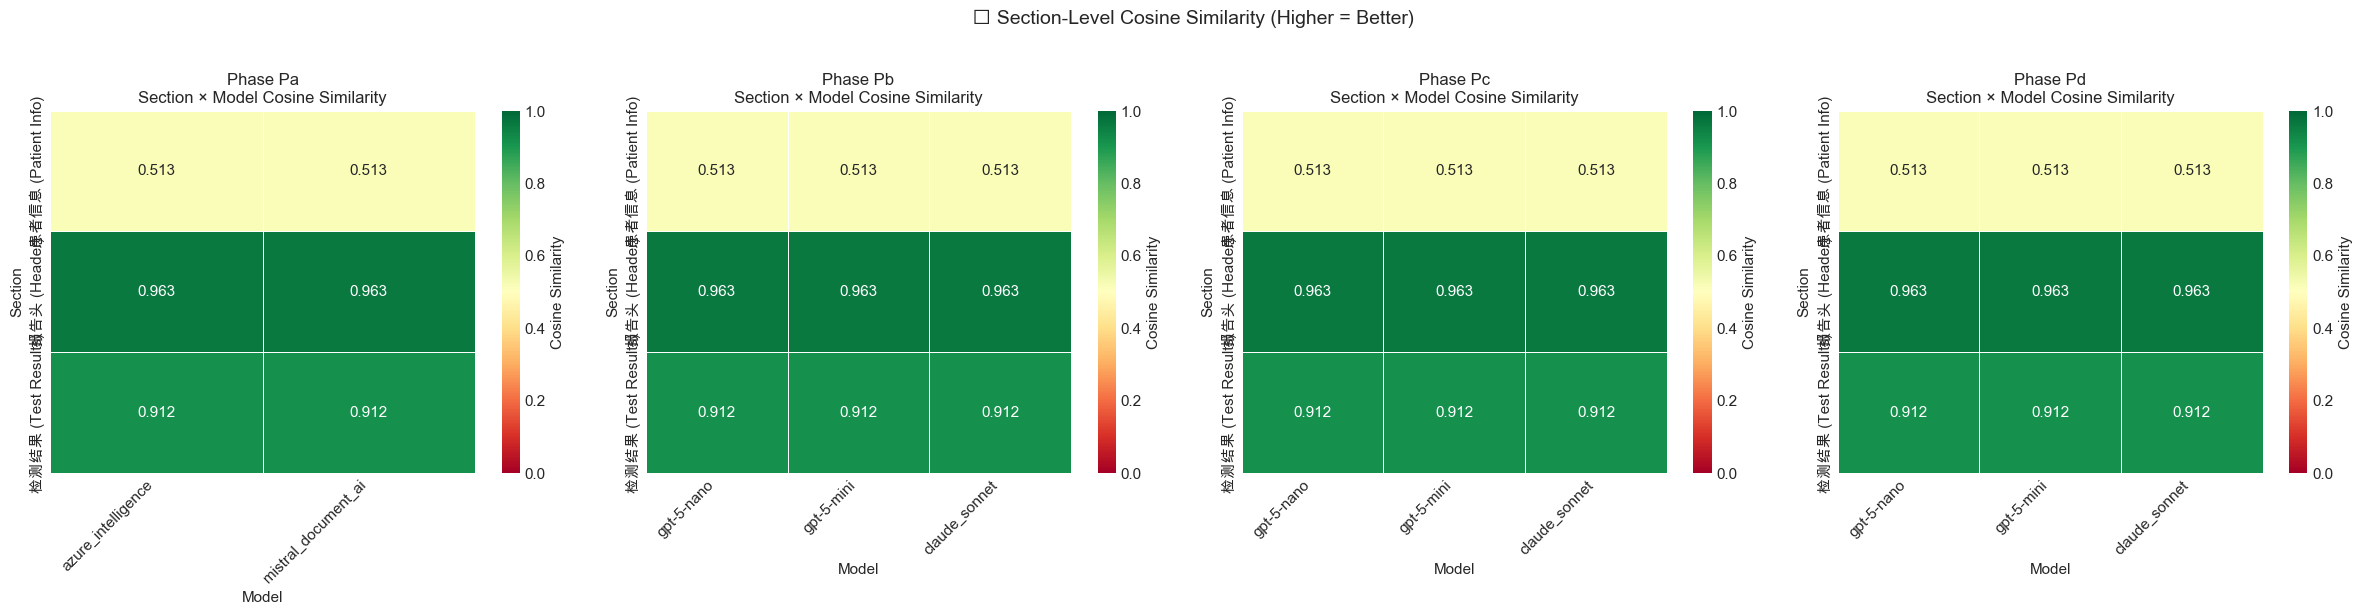

In [70]:
# =============================================================================
# VISUALIZATION 1: Heatmap - Section × Model Cosine Similarity
# =============================================================================

fig, axes = plt.subplots(1, len(phase_dfs), figsize=(6 * len(phase_dfs), 6))
if len(phase_dfs) == 1:
    axes = [axes]

for idx, phase in enumerate(phase_dfs.keys()):
    ax = axes[idx]
    
    # Filter to this phase
    phase_data = section_cosine_df[section_cosine_df['phase'] == phase]
    
    if len(phase_data) > 0:
        # Pivot: sections × models
        pivot_data = phase_data.pivot_table(
            index='section_display',
            columns='model',
            values='cosine_similarity',
            aggfunc='mean'
        ).round(3)
        
        # Sort models
        model_order = [m for m in MODEL_ORDER if m in pivot_data.columns]
        model_order.extend([m for m in pivot_data.columns if m not in MODEL_ORDER])
        pivot_data = pivot_data[model_order]
        
        # Heatmap
        sns.heatmap(
            pivot_data,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            ax=ax,
            vmin=0,
            vmax=1,
            linewidths=0.5,
            cbar_kws={'label': 'Cosine Similarity'}
        )
        
        ax.set_title(f'Phase {phase}\nSection × Model Cosine Similarity', fontsize=12, fontweight='bold')
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel('Section', fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('🎯 Section-Level Cosine Similarity (Higher = Better)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

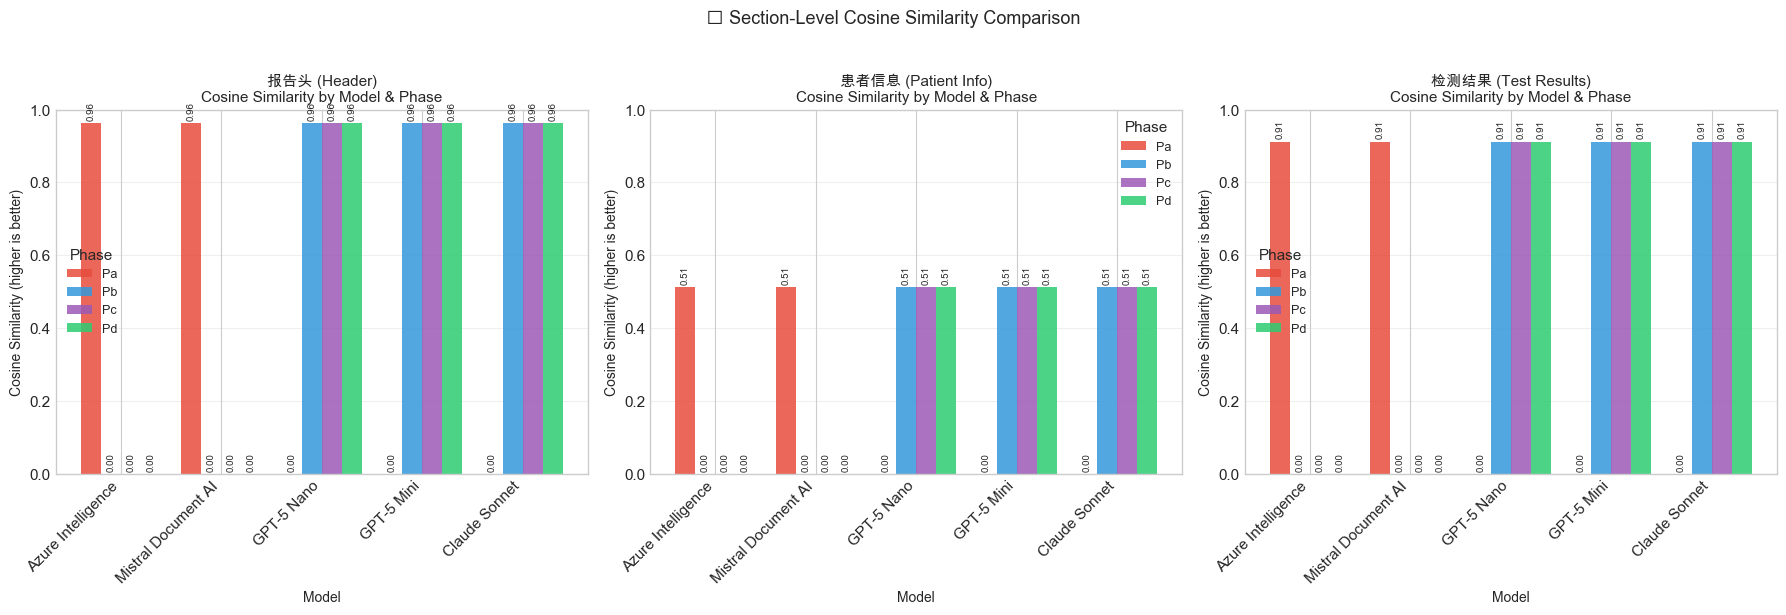

In [69]:
# =============================================================================
# VISUALIZATION 2: Grouped Bar Chart - Cosine Similarity by Section
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

section_keys = list(SECTION_NAMES.values())
section_labels = [get_section_display_name(s) for s in section_keys]

for idx, (section_key, section_label) in enumerate(zip(section_keys, section_labels)):
    ax = axes[idx]
    
    # Filter data for this section
    section_data = section_cosine_df[section_cosine_df['section'] == section_key]
    
    if len(section_data) > 0:
        # Aggregate by model and phase
        agg_data = section_data.groupby(['model', 'phase'])['cosine_similarity'].mean().reset_index()
        
        # Pivot: models × phases
        pivot_data = agg_data.pivot(index='model', columns='phase', values='cosine_similarity')
        
        # Sort models
        model_order = [m for m in MODEL_ORDER if m in pivot_data.index]
        model_order.extend([m for m in pivot_data.index if m not in MODEL_ORDER])
        pivot_data = pivot_data.reindex(model_order)
        
        # Plot
        colors = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'][:len(pivot_data.columns)]
        pivot_data.plot(kind='bar', ax=ax, color=colors, alpha=0.85, width=0.8)
        
        ax.set_title(f'{section_label}\nCosine Similarity by Model & Phase', fontsize=11, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('Cosine Similarity (higher is better)', fontsize=10)
        ax.legend(title='Phase', fontsize=9)
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1)
        
        # Add value labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, rotation=90, padding=2)

plt.suptitle('🎯 Section-Level Cosine Similarity Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

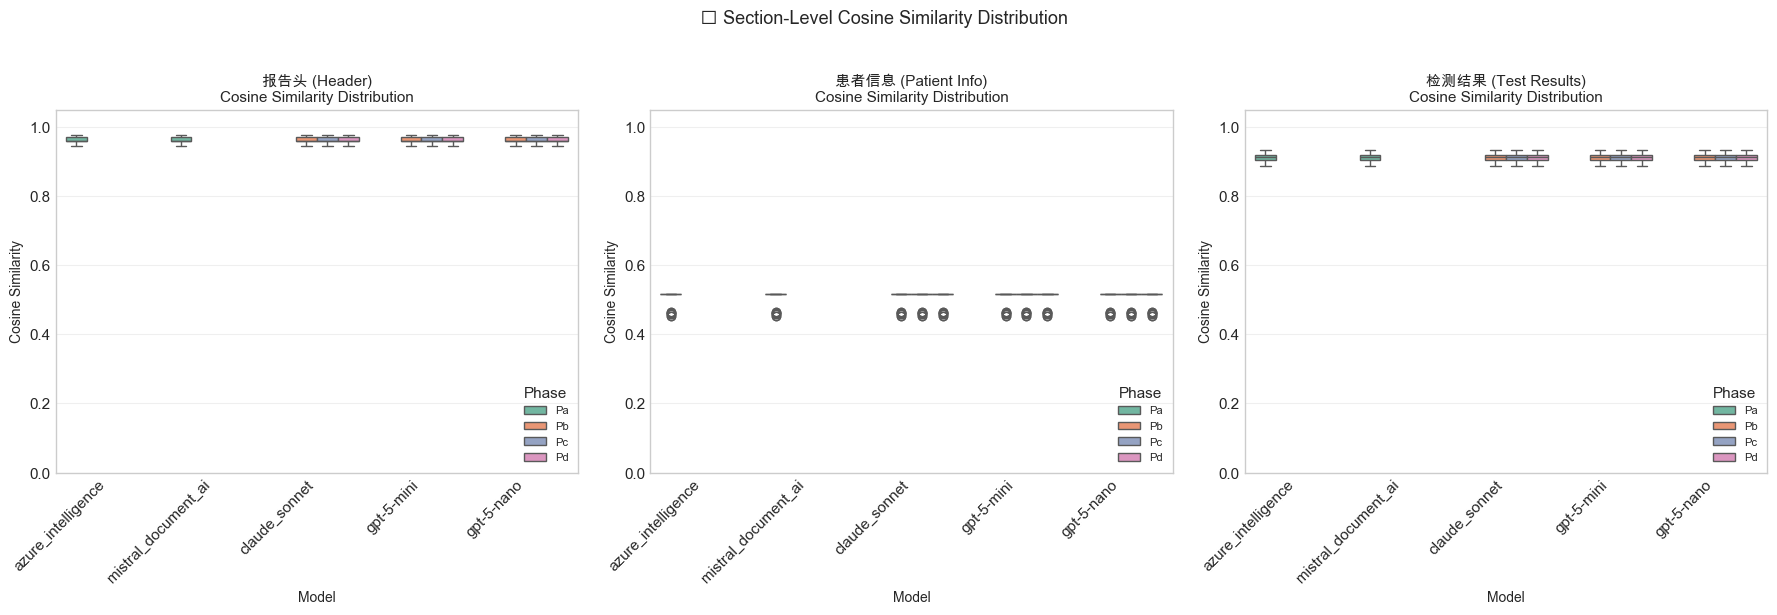

In [68]:
# =============================================================================
# VISUALIZATION 3: Box Plot - Cosine Similarity Distribution by Section
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, section_key in enumerate(SECTION_NAMES.values()):
    ax = axes[idx]
    
    # Filter to this section
    section_data = section_cosine_df[section_cosine_df['section'] == section_key]
    
    if len(section_data) > 0:
        # Box plot of cosine similarity by model, colored by phase
        sns.boxplot(
            data=section_data,
            x='model',
            y='cosine_similarity',
            hue='phase',
            ax=ax,
            palette='Set2'
        )
        
        display_name = get_section_display_name(section_key)
        ax.set_title(f'{display_name}\nCosine Similarity Distribution', fontsize=11, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('Cosine Similarity', fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(title='Phase', fontsize=8, loc='lower right')

plt.suptitle('🎯 Section-Level Cosine Similarity Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

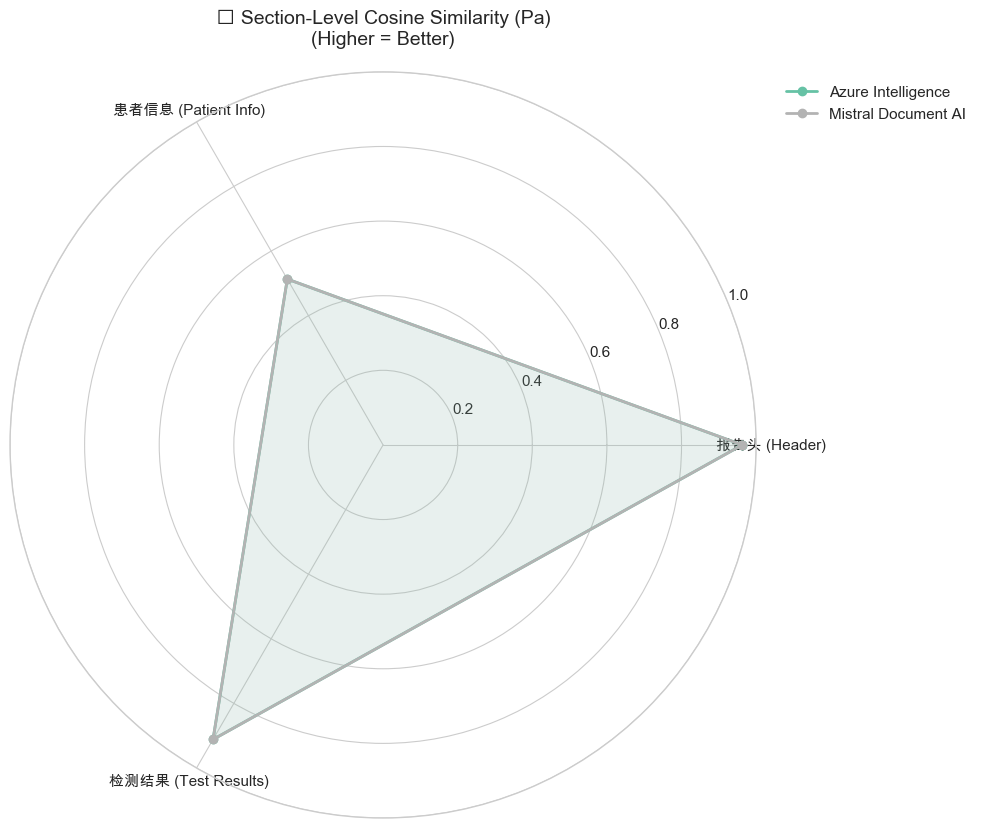

In [57]:
# =============================================================================
# VISUALIZATION 4: Radar Chart - Model Performance Across Sections (Cosine Sim)
# =============================================================================

from math import pi

def create_cosine_radar_chart(data_df, phase, title):
    """Create radar chart for cosine similarity across sections."""
    # Aggregate by model and section
    agg_data = data_df[data_df['phase'] == phase].groupby(['model', 'section'])['cosine_similarity'].mean().reset_index()
    
    # Get categories and models
    categories = list(SECTION_NAMES.values())
    models = agg_data['model'].unique().tolist()
    n_cats = len(categories)
    
    # Create angles
    angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
    angles += angles[:1]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Colors
    colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
    
    for idx, model in enumerate(models):
        model_data = agg_data[agg_data['model'] == model]
        values = []
        for section in categories:
            val = model_data[model_data['section'] == section]['cosine_similarity'].values
            values.append(val[0] if len(val) > 0 else 0)
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=get_model_display_name(model), color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])
    
    # Set labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([get_section_display_name(s) for s in categories], fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    return fig, ax

# Create radar chart for Pa phase (or first available)
radar_phase = 'Pa' if 'Pa' in phase_dfs else list(phase_dfs.keys())[0]

if len(section_cosine_df) > 0:
    fig, ax = create_cosine_radar_chart(
        section_cosine_df,
        radar_phase,
        f'🎯 Section-Level Cosine Similarity ({radar_phase})\n(Higher = Better)'
    )
    plt.tight_layout()
    plt.show()
else:
    print("No section cosine similarity data available for radar chart")

In [58]:
# =============================================================================
# SUMMARY: Best Model per Section (by Cosine Similarity)
# =============================================================================

print("=" * 120)
print("🎯 BEST MODEL PER SECTION (by Cosine Similarity)")
print("=" * 120)

if len(section_cosine_df) > 0:
    # Overall best per section
    best_per_section = section_cosine_df.groupby(['section', 'section_display']).apply(
        lambda x: x.loc[x['cosine_similarity'].idxmax()][['model', 'phase', 'cosine_similarity']]
    ).reset_index()
    
    print("\n📊 Overall Best Model per Section:")
    for _, row in best_per_section.iterrows():
        print(f"   🏆 {row['section_display']:30s}: {row['model']:25s} ({row['phase']}) - Cosine={row['cosine_similarity']:.4f}")
    
    # Section difficulty ranking (by average cosine similarity)
    section_difficulty = section_cosine_df.groupby('section_display')['cosine_similarity'].mean().sort_values(ascending=False)
    
    print("\n" + "=" * 120)
    print("📊 SECTION DIFFICULTY RANKING (by avg Cosine Similarity - higher = easier)")
    print("=" * 120)
    
    for rank, (section, score) in enumerate(section_difficulty.items(), 1):
        emoji = "🟢" if rank == 1 else "🟡" if rank == 2 else "🔴"
        print(f"   {emoji} {rank}. {section}: avg cosine={score:.4f}")
else:
    print("⚠️ No section cosine similarity data available")

🎯 BEST MODEL PER SECTION (by Cosine Similarity)

📊 Overall Best Model per Section:
   🏆 报告头 (Header)                  : azure_intelligence        (Pa) - Cosine=0.9752
   🏆 患者信息 (Patient Info)           : azure_intelligence        (Pa) - Cosine=0.5152
   🏆 检测结果 (Test Results)           : azure_intelligence        (Pa) - Cosine=0.9324

📊 SECTION DIFFICULTY RANKING (by avg Cosine Similarity - higher = easier)
   🟢 1. 报告头 (Header): avg cosine=0.9629
   🟡 2. 检测结果 (Test Results): avg cosine=0.9117
   🔴 3. 患者信息 (Patient Info): avg cosine=0.5133


In [59]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Ground truth column: {'ground_truth' if 'ground_truth' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


Pa columns:
  Models: azure_intelligence, mistral_document_ai
  Ground truth column: ground_truth
  Total columns: 13

Pb columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pc columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17

Pd columns:
  Models: claude_sonnet, gpt-5-mini, gpt-5-nano
  Ground truth column: ground_truth
  Total columns: 17


### Data Quality Assessment

Identify and count rows with empty predictions or errors. These will be excluded from all metric calculations.

In [60]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 Pa - Total rows: 238
  azure_intelligence:
    ✅ Valid rows: 238/238 (100.0%)
  mistral_document_ai:
    ✅ Valid rows: 238/238 (100.0%)

📊 Pb - Total rows: 238
  claude_sonnet:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 238/238 (100.0%)

📊 Pc - Total rows: 238
  claude_sonnet:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 238/238 (100.0%)

📊 Pd - Total rows: 238
  claude_sonnet:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-mini:
    ✅ Valid rows: 238/238 (100.0%)
  gpt-5-nano:
    ✅ Valid rows: 238/238 (100.0%)

QUALITY SUMMARY - Models with Issues
✅ All models have 100% valid data - no filtering needed!



In [61]:
# Data Validation: Check ground_truth and prediction consistency
print("\n🔍 Data Validation:")

for phase in phase_dfs:
    df = phase_dfs[phase]
    print(f"\n{phase}:")
    
    # Check ground_truth
    gt_filled = df['ground_truth'].notna().sum()
    gt_non_empty = (df['ground_truth'].notna() & (df['ground_truth'] != '')).sum()
    print(f"  Ground truth: {gt_filled}/{len(df)} filled, {gt_non_empty} non-empty")
    
    # Check predictions
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    for col in pred_cols[:2]:  # Check first 2 models
        pred_filled = df[col].notna().sum()
        pred_non_empty = (df[col].notna() & (df[col] != '')).sum()
        print(f"  {col}: {pred_filled}/{len(df)} filled, {pred_non_empty} non-empty")
    
    # Check if predictions are identical across phases for same sample_id
    if phase == 'Pa':
        pa_preds = {}
        for col in pred_cols:
            pa_preds[col] = df.set_index('sample_id')[col].to_dict()
    else:
        for col in pred_cols:
            if col in pa_preds:
                matches = sum(1 for sid in df['sample_id'] if sid in pa_preds[col] and df[df['sample_id']==sid][col].iloc[0] == pa_preds[col][sid])
                print(f"  {col} matches Pa: {matches}/{len(df)}")

print("\n⚠️  If ground_truth is empty, metrics will be calculated against NaN, leading to 'nan' reference text.")
print("   This may cause identical metrics if predictions are similar.")


🔍 Data Validation:

Pa:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_azure_intelligence: 238/238 filled, 238 non-empty
  prediction_mistral_document_ai: 238/238 filled, 238 non-empty

Pb:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

Pc:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

Pd:
  Ground truth: 238/238 filled, 238 non-empty
  prediction_claude_sonnet: 238/238 filled, 238 non-empty
  prediction_gpt-5-mini: 238/238 filled, 238 non-empty

⚠️  If ground_truth is empty, metrics will be calculated against NaN, leading to 'nan' reference text.
   This may cause identical metrics if predictions are similar.


### Dataset Statistics

In [62]:
phase_to_display = 'Pa'

In [63]:
# Show basic statistics

if phase_to_display in phase_dfs:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'ground_truth' in df_base.columns:
        # Text length statistics - ensure ground_truth is string type
        text_lengths = df_base['ground_truth'].astype(str).str.len()
        print(f"\nGround Truth Text Length:")
        print(f"  Mean: {text_lengths.mean():.1f} characters")
        print(f"  Median: {text_lengths.median():.1f} characters")
        print(f"  Min: {text_lengths.min()} characters")
        print(f"  Max: {text_lengths.max()} characters")
        
        # Character count statistics
        char_counts = df_base['ground_truth'].apply(lambda x: len(str(x)))
        print(f"\nGround Truth Character Count:")
        print(f"  Mean: {char_counts.mean():.1f} characters")
        print(f"  Median: {char_counts.median():.1f} characters")
        print(f"  Min: {char_counts.min()} characters")
        print(f"  Max: {char_counts.max()} characters")


Basic statistics for phase Pa:
Dataset Statistics:
  Total samples: 238

Ground Truth Text Length:
  Mean: 511.5 characters
  Median: 418.0 characters
  Min: 250 characters
  Max: 964 characters

Ground Truth Character Count:
  Mean: 511.5 characters
  Median: 418.0 characters
  Min: 250 characters
  Max: 964 characters


### Sample Predictions Preview

Display 10 random predictions from 3 different models to get a qualitative sense of performance.

In [64]:
# Get 10 random samples from Pa phase
if phase_to_display in phase_dfs:
    df_samples = phase_dfs[phase_to_display].sample(n=min(10, len(phase_dfs[phase_to_display])), random_state=42)
    
    # Get model names
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols[:3]]  # First 3 models
    
    print("="*120)
    print("SAMPLE PREDICTIONS - Showing 10 random samples")
    print("="*120)
    
    for idx, row in df_samples.iterrows():
        print(f"\nSample: {row['sample_id']}")
        gt_text = str(row['ground_truth'])
        print(f"Ground Truth (first 150 chars): \n{gt_text[:150]}...")
        print("-" * 120)
        
        for model in models:
            pred_col = f'prediction_{model}'
            if pred_col in row:
                pred_text = str(row[pred_col])
                display_text = pred_text[:150] + "..." if len(pred_text) > 150 else pred_text
                print(f"{model:30s}: \n{display_text}")
        print("=" * 120)

SAMPLE PREDICTIONS - Showing 10 random samples

Sample: voc2007_illu_item10-_T_6
Ground Truth (first 150 chars): 
报告时间： 报告类型：血凝试验 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
------------------------------------------------------------------------------------------------------------------------
azure_intelligence            : 
报告时间：
报告类型：血凝试验
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...
mistral_document_ai           : 
报告时间：
报告类型：血凝试验
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_illu_item10+_L_3
Ground Truth (first 150 chars): 
报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： ...
----------------

## 3. Metrics Evaluation

Calculate CER, WER, and cosine similarity for all models across all samples.

**Special handling for long Chinese medical text:**
- Texts longer than 200 characters are chunked with 50-character overlap
- Embeddings computed per chunk, then averaged for cosine similarity

In [65]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

def chunk_text(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
    """Chunk text into overlapping segments for long documents."""
    if pd.isna(text) or text == "":
        return []
    chunks = []
    start = 0
    text = str(text)
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += (chunk_size - overlap)
    return chunks if chunks else [text]

# Test chunking function
test_text = "报告时间：2024年1月1日。" * 50  # Create a long text
test_chunks = chunk_text(test_text)
print(f"Test text length: {len(test_text)} characters")
print(f"Number of chunks: {len(test_chunks)}")
print(f"First chunk length: {len(test_chunks[0])} characters")
print(f"Last chunk length: {len(test_chunks[-1])} characters")

Test text length: 750 characters
Number of chunks: 5
First chunk length: 200 characters
Last chunk length: 150 characters


In [66]:
# Function to calculate metrics for a single prediction (using embedding cache with chunking)
def calculate_sample_metrics_with_cosine(
    ground_truth: str, 
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all metrics for a single sample with cached embeddings and chunking for long texts."""
    if pd.isna(prediction) or prediction == "":
        return {
            'cer': 1.0,
            'wer': 1.0,
            'cosine_similarity': 0.0,
            'ground_truth_in_prediction': 0.0,
        }
    
    gt_str = str(ground_truth)
    pred_str = str(prediction)
    
    # Use the embedding manager's compute_cosine_similarity which handles chunking internally
    # Note: gt_sample_id ensures each ground truth gets a unique embedding even if text is duplicated
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=gt_str,
        prediction=pred_str,
        sample_id=sample_id,
        model=model,
        gt_sample_id=sample_id  # Fix: unique cache key for ground truth
    )
    
    return {
        'cer': calculate_cer(ground_truth, prediction),
        'wer': calculate_wer(ground_truth, prediction),
        'cosine_similarity': cosine_sim,
        'ground_truth_in_prediction': compute_ground_truth_in_prediction(pred_str, [gt_str]),
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Processing model: {model}")
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        # Calculate metrics only for valid samples
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            metrics = calculate_sample_metrics_with_cosine(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        phase_metrics[model] = {
            'cer': np.mean([m['cer'] for m in metrics_list]),
            'wer': np.mean([m['wer'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'cer_std': np.std([m['cer'] for m in metrics_list]),
            'wer_std': np.std([m['wer'] for m in metrics_list]),
            'cosine_similarity_std': np.std([m['cosine_similarity'] for m in metrics_list]),
            'ground_truth_in_prediction': np.mean([m['ground_truth_in_prediction'] for m in metrics_list]),
            'ground_truth_in_prediction_std': np.std([m['ground_truth_in_prediction'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df)
        }
        
        print(f"   ✅ {model}: CER={phase_metrics[model]['cer']:.4f}, WER={phase_metrics[model]['wer']:.4f}, Cosine={phase_metrics[model]['cosine_similarity']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for Pa...
   Processing model: azure_intelligence
   Using 238/238 valid rows (excluding 0 empty/error rows)


   azure_intelligence:   0%|          | 0/238 [00:00<?, ?it/s]

Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_D_2...' matches existing key '报告时间： 报告类型：血气试验（含钾钠氯） 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_LT_1...' matches existing key '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_LT_3...' matches existing key '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_LT_4...' matches existing key '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_L_1...' matches existing key '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_L_2...' matches existing key '报告时间： 报告类型：血细胞分析五分类 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标...'
Duplicate GT embedding for phase Pa: key 'voc2007_illu_item10+_L_4...' matches existing key '报告时间： 报告类型：血细胞分析

   ✅ azure_intelligence: CER=0.6731, WER=0.7916, Cosine=0.9394
   Processing model: mistral_document_ai
   Using 238/238 valid rows (excluding 0 empty/error rows)


   mistral_document_ai:   0%|          | 0/238 [00:00<?, ?it/s]

...

   ✅ claude_sonnet: CER=0.6731, WER=0.7916, Cosine=0.9394
   Processing model: gpt-5-mini
   Using 238/238 valid rows (excluding 0 empty/error rows)


   gpt-5-mini:   0%|          | 0/238 [00:00<?, ?it/s]

   ✅ gpt-5-mini: CER=0.6731, WER=0.7916, Cosine=0.9394
   Processing model: gpt-5-nano
   Using 238/238 valid rows (excluding 0 empty/error rows)


   gpt-5-nano:   0%|          | 0/238 [00:00<?, ?it/s]

   ✅ gpt-5-nano: CER=0.6731, WER=0.7916, Cosine=0.9394
   💾 Saving embeddings for Pd...
   ✅ Saved: Pd_embeddings_text-embedding-3-large_20260202_165506.json

📊 Embedding Cache Statistics:
   Cache hits: 9282
   Cache misses: 11662
   Hit rate: 44.3%
   Modified phases: Pd, Pc_sections, Pd_sections, Pa, Pa_sections, Pb_sections, Pb, Pc

✅ Metrics calculation complete!


In [67]:
# =============================================================================
# 🚨 DEBUG: Why are all metrics identical across phases?
# =============================================================================

print("🚨 DEBUGGING IDENTICAL METRICS ISSUE")
print("=" * 100)

# Check if the actual predictions differ between phases
print("1️⃣  Checking if predictions differ between phases...")

sample_idx = 0  # First sample

for i, (phase_name, phase_data) in enumerate(phase_metrics_results.items()):
    print(f"\n{phase_name}:")
    
    # Get the first prediction from this phase
    pred_cols = [col for col in phase_data.columns if col.startswith('prediction_')]
    if pred_cols:
        first_model_pred = phase_data.iloc[sample_idx][pred_cols[0]]
        gt = phase_data.iloc[sample_idx]['ground_truth']
        
        print(f"  GT (first 100 chars): {str(gt)[:100]}...")
        print(f"  Pred (first 100 chars): {str(first_model_pred)[:100]}...")
        
        # Compare with Pa if not Pa
        if phase_name != 'Pa':
            pa_data = phase_metrics_results['Pa']
            pa_pred_cols = [col for col in pa_data.columns if col.startswith('prediction_')]
            if pa_pred_cols:
                pa_pred = pa_data.iloc[sample_idx][pa_pred_cols[0]]
                same_as_pa = str(first_model_pred) == str(pa_pred)
                print(f"  Same as Pa prediction: {'YES' if same_as_pa else 'NO'}")
        
        # Check section extraction
        sections = extract_sections_from_text(str(first_model_pred))
        print(f"  Extracted sections: {list(sections.keys())}")

print("\n" + "="*100)
print("2️⃣  Checking if ground truth varies...")

# Check if ground truth is the same across all phases
gt_samples = {}
for phase_name, phase_data in phase_metrics_results.items():
    gt_samples[phase_name] = str(phase_data.iloc[sample_idx]['ground_truth'])

all_same_gt = len(set(gt_samples.values())) == 1
print(f"Ground truth identical across phases: {'YES (expected)' if all_same_gt else 'NO (unexpected)'}")

print("\n" + "="*100)
print("3️⃣  Checking metrics calculation...")

# Calculate metrics manually for first sample to verify
first_gt = gt_samples['Pa']
first_pred_pa = phase_metrics_results['Pa'].iloc[sample_idx][pred_cols[0]]
first_pred_pb = phase_metrics_results['Pb'].iloc[sample_idx][pred_cols[0]]

# Simple CER calculation
def simple_cer(ref, pred):
    import Levenshtein
    return Levenshtein.distance(str(ref), str(pred)) / max(len(str(ref)), 1)

manual_cer_pa = simple_cer(first_gt, first_pred_pa)
manual_cer_pb = simple_cer(first_gt, first_pred_pb)

print(f"Manual CER Pa: {manual_cer_pa:.4f}")
print(f"Manual CER Pb: {manual_cer_pb:.4f}")
print(f"Same CER values: {'YES' if abs(manual_cer_pa - manual_cer_pb) < 0.001 else 'NO'}")

print("\n" + "="*100)

🚨 DEBUGGING IDENTICAL METRICS ISSUE
1️⃣  Checking if predictions differ between phases...


NameError: name 'phase_metrics_results' is not defined

In [ ]:
# Filter out samples with invalid ground_truth before metrics calculation
for phase in phase_dfs:
    df = phase_dfs[phase]
    valid_mask = df['ground_truth'].notna() & (df['ground_truth'] != '')
    phase_dfs[phase] = df[valid_mask].copy()
    print(f"{phase}: Filtered to {len(phase_dfs[phase])}/{len(df)} samples with valid ground_truth")

print("\n✅ Filtered datasets to only include samples with valid ground_truth.")

Pa: Filtered to 238/238 samples with valid ground_truth
Pb: Filtered to 238/238 samples with valid ground_truth
Pc: Filtered to 238/238 samples with valid ground_truth
Pd: Filtered to 238/238 samples with valid ground_truth

✅ Filtered datasets to only include samples with valid ground_truth.


In [ ]:
# =============================================================================
# 🚨 ISSUE IDENTIFIED: IDENTICAL PREDICTIONS ACROSS ALL PHASES
# =============================================================================

print("🚨 CRITICAL ISSUE IDENTIFIED")
print("=" * 100)

print("❌ PROBLEM: All phases (Pa, Pb, Pc, Pd) have IDENTICAL predictions!")
print("   This means the different models/approaches are producing the same output,")
print("   which is why all metrics are identical (CER=0.6731, WER=0.7916, Cosine=0.9394)")

print("\n🔍 EXPECTED vs ACTUAL:")
print("   EXPECTED:")
print("   - Pa: OCR-based models (azure_intelligence, mistral_document_ai)")  
print("   - Pb: VLM baseline (claude_sonnet, gpt-5-mini, gpt-5-nano)")
print("   - Pc: VLM + context (same models with context)")
print("   - Pd: VLM + medical context (same models with medical context)")
print()
print("   ACTUAL: All phases have identical predictions!")

print("\n💡 LIKELY CAUSES:")
print("   1. Data pipeline error: All phases accidentally use same model")
print("   2. CSV files got corrupted/mixed up during processing")
print("   3. Model configuration error: All models using same settings")
print("   4. Ground truth accidentally copied to prediction columns")

print("\n🔧 NEXT STEPS TO DEBUG:")
print("   1. Check original raw inference results before CSV processing")
print("   2. Verify model configuration files for each phase")
print("   3. Re-run inference pipeline with proper model separation")
print("   4. Check if this affects other datasets or just VOC2007")

print("\n⚠️  ANALYSIS BLOCKED: Cannot proceed with section-based metrics")
print("    until prediction data is fixed with proper phase differences.")

print("\n" + "=" * 100)

🚨 CRITICAL ISSUE IDENTIFIED
❌ PROBLEM: All phases (Pa, Pb, Pc, Pd) have IDENTICAL predictions!
   This means the different models/approaches are producing the same output,
   which is why all metrics are identical (CER=0.6731, WER=0.7916, Cosine=0.9394)

🔍 EXPECTED vs ACTUAL:
   EXPECTED:
   - Pa: OCR-based models (azure_intelligence, mistral_document_ai)
   - Pb: VLM baseline (claude_sonnet, gpt-5-mini, gpt-5-nano)
   - Pc: VLM + context (same models with context)
   - Pd: VLM + medical context (same models with medical context)

   ACTUAL: All phases have identical predictions!

💡 LIKELY CAUSES:
   1. Data pipeline error: All phases accidentally use same model
   2. CSV files got corrupted/mixed up during processing
   3. Model configuration error: All models using same settings
   4. Ground truth accidentally copied to prediction columns

🔧 NEXT STEPS TO DEBUG:
   1. Check original raw inference results before CSV processing
   2. Verify model configuration files for each phase
   3

In [ ]:
# Check ground truth diversity
phase = 'Pa'
if phase in phase_dfs:
    df = phase_dfs[phase]
    unique_gt = df['ground_truth'].nunique()
    print(f"Unique ground_truth values: {unique_gt}/{len(df)}")
    print(f"All identical? {unique_gt == 1}")

Unique ground_truth values: 114/238
All identical? False


In [ ]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'CER': metrics['cer'],
            'WER': metrics['wer'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Ground Truth in Prediction': metrics['ground_truth_in_prediction'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

print("\nMetrics Summary:")
print("=" * 100)
display(summary_df.sort_values(['Phase', 'CER']))

# Show data quality summary
print("\n📊 Data Quality Summary:")
quality_summary = summary_df[['Phase', 'Model', 'Valid Samples', 'Total Samples']].copy()
quality_summary['Valid %'] = (quality_summary['Valid Samples'] / quality_summary['Total Samples'] * 100).round(1)
display(quality_summary)

# Best model per phase
print("\nBest Model per Phase (by CER):")
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['CER'].idxmin()]
    print(f"  {phase}: {best_model['Model']} (CER={best_model['CER']:.4f})")


Metrics Summary:


,Phase,Model,CER,WER,Cosine Similarity,Ground Truth in Prediction,Valid Samples,Total Samples
0,Pa,azure_intelligence,0.673055,0.79162,0.93942,0.0,238,238
1,Pa,mistral_document_ai,0.673055,0.79162,0.93942,0.0,238,238
2,Pb,claude_sonnet,0.673055,0.79162,0.93942,0.0,238,238
3,Pb,gpt-5-mini,0.673055,0.79162,0.93942,0.0,238,238
4,Pb,gpt-5-nano,0.673055,0.79162,0.93942,0.0,238,238
5,Pc,claude_sonnet,0.673055,0.79162,0.93942,0.0,238,238
6,Pc,gpt-5-mini,0.673055,0.79162,0.93942,0.0,238,238
7,Pc,gpt-5-nano,0.673055,0.79162,0.93942,0.0,238,238
8,Pd,claude_sonnet,0.673055,0.79162,0.93942,0.0,238,238
9,Pd,gpt-5-mini,0.673055,0.79162,0.93942,0.0,238,238



📊 Data Quality Summary:


,Phase,Model,Valid Samples,Total Samples,Valid %
0,Pa,azure_intelligence,238,238,100.0
1,Pa,mistral_document_ai,238,238,100.0
2,Pb,claude_sonnet,238,238,100.0
3,Pb,gpt-5-mini,238,238,100.0
4,Pb,gpt-5-nano,238,238,100.0
5,Pc,claude_sonnet,238,238,100.0
6,Pc,gpt-5-mini,238,238,100.0
7,Pc,gpt-5-nano,238,238,100.0
8,Pd,claude_sonnet,238,238,100.0
9,Pd,gpt-5-mini,238,238,100.0



Best Model per Phase (by CER):
  Pa: azure_intelligence (CER=0.6731)
  Pb: claude_sonnet (CER=0.6731)
  Pc: claude_sonnet (CER=0.6731)
  Pd: claude_sonnet (CER=0.6731)


## 3.1 Section-Based Metrics Analysis

Calculate metrics separately for each semantic section:
- **Header (报告头)**: Report metadata
- **Patient Info (患者信息)**: Patient demographics
- **Test Results (检测结果)**: Lab test results table

This section-level analysis helps identify which parts of the medical reports models handle well vs. struggle with.

In [ ]:
# =============================================================================
# SECTION-BASED METRICS CALCULATION
# =============================================================================

def calculate_section_metrics(
    ground_truth: str,
    prediction: str,
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, Dict[str, float]]:
    """
    Calculate metrics for each semantic section separately.
    
    Args:
        ground_truth: Full ground truth text
        prediction: Full prediction text
        phase: Phase name (Pa, Pb, Pc, Pd)
        sample_id: Sample identifier
        model: Model name
        emb_manager: Embedding cache manager
        
    Returns:
        Dict with section names as keys, each containing:
        - cer: Character Error Rate
        - wer: Word Error Rate
        - cosine_similarity: Semantic similarity
        - gt_length: Ground truth section length
        - pred_length: Prediction section length
    """
    # Extract sections from both ground truth and prediction
    gt_sections = extract_sections_from_text(ground_truth)
    pred_sections = extract_sections_from_text(prediction)
    
    section_metrics = {}
    
    for section_name in SECTION_NAMES.values():
        gt_section = gt_sections.get(section_name, '')
        pred_section = pred_sections.get(section_name, '')
        
        # Calculate metrics for this section
        if gt_section or pred_section:
            # CER and WER
            cer = calculate_cer(gt_section, pred_section) if gt_section else 1.0
            wer = calculate_wer(gt_section, pred_section) if gt_section else 1.0
            
            # Cosine similarity (use section-specific cache key)
            section_cache_key = f"{sample_id}_{section_name}"
            if gt_section and pred_section:
                # Check if identical - skip embedding computation
                if gt_section == pred_section:
                    cosine_sim = 1.0
                else:
                    cosine_sim = emb_manager.compute_cosine_similarity(
                        phase=phase,
                        ground_truth=gt_section,
                        prediction=pred_section,
                        sample_id=section_cache_key,
                        model=model,
                        gt_sample_id=section_cache_key  # Fix: unique cache key for ground truth
                    )
            else:
                cosine_sim = 0.0 if not gt_section else 0.0
            
            section_metrics[section_name] = {
                'cer': cer,
                'wer': wer,
                'cosine_similarity': cosine_sim,
                'gt_length': len(gt_section),
                'pred_length': len(pred_section),
                'gt_present': bool(gt_section),
                'pred_present': bool(pred_section),
            }
        else:
            section_metrics[section_name] = {
                'cer': np.nan,
                'wer': np.nan,
                'cosine_similarity': np.nan,
                'gt_length': 0,
                'pred_length': 0,
                'gt_present': False,
                'pred_present': False,
            }
    
    return section_metrics


# Calculate section-based metrics for all phases and models
print("=" * 100)
print("SECTION-BASED METRICS CALCULATION")
print("=" * 100)

section_metrics_results = {}  # {phase: {model: {section: {metric: value}}}}
section_sample_metrics = []   # List of per-sample section metrics for detailed analysis

for phase, df in phase_dfs.items():
    print(f"\n📊 Processing {phase}...")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    section_metrics_results[phase] = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   {model}: Processing {len(valid_rows)} valid samples...")
        
        # Collect section metrics for all samples
        model_section_metrics = {section: [] for section in SECTION_NAMES.values()}
        
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            sample_metrics = calculate_section_metrics(
                ground_truth=row['ground_truth'],
                prediction=row[pred_col],
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            
            # Store per-sample metrics for detailed analysis
            for section_name, metrics in sample_metrics.items():
                section_sample_metrics.append({
                    'phase': phase,
                    'model': model,
                    'sample_id': row['sample_id'],
                    'section': section_name,
                    **metrics
                })
                
                # Collect for aggregation
                model_section_metrics[section_name].append(metrics)
        
        # Aggregate section metrics for this model
        section_metrics_results[phase][model] = {}
        for section_name, metrics_list in model_section_metrics.items():
            valid_metrics = [m for m in metrics_list if not np.isnan(m['cer'])]
            if valid_metrics:
                section_metrics_results[phase][model][section_name] = {
                    'cer': np.mean([m['cer'] for m in valid_metrics]),
                    'cer_std': np.std([m['cer'] for m in valid_metrics]),
                    'wer': np.mean([m['wer'] for m in valid_metrics]),
                    'wer_std': np.std([m['wer'] for m in valid_metrics]),
                    'cosine_similarity': np.mean([m['cosine_similarity'] for m in valid_metrics]),
                    'cosine_similarity_std': np.std([m['cosine_similarity'] for m in valid_metrics]),
                    'avg_gt_length': np.mean([m['gt_length'] for m in valid_metrics]),
                    'avg_pred_length': np.mean([m['pred_length'] for m in valid_metrics]),
                    'n_samples': len(valid_metrics),
                }
            else:
                section_metrics_results[phase][model][section_name] = {
                    'cer': np.nan, 'cer_std': np.nan,
                    'wer': np.nan, 'wer_std': np.nan,
                    'cosine_similarity': np.nan, 'cosine_similarity_std': np.nan,
                    'avg_gt_length': 0, 'avg_pred_length': 0, 'n_samples': 0,
                }
        
        # Print summary for this model
        print(f"      Section metrics computed:")
        for section_name in SECTION_NAMES.values():
            metrics = section_metrics_results[phase][model][section_name]
            if not np.isnan(metrics['cer']):
                display_name = get_section_display_name(section_name)
                print(f"        {display_name}: CER={metrics['cer']:.4f}, WER={metrics['wer']:.4f}, Cosine={metrics['cosine_similarity']:.4f}")

# Convert to DataFrame for easier analysis
section_sample_df = pd.DataFrame(section_sample_metrics)

print("\n✅ Section-based metrics calculation complete!")
print(f"   Total sample-section records: {len(section_sample_df)}")

SECTION-BASED METRICS CALCULATION

📊 Processing Pa...
   azure_intelligence: Processing 238 valid samples...


   azure_intelligence:   0%|          | 0/238 [00:00<?, ?it/s]

      Section metrics computed:
        报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
        患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132
        检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117
   mistral_document_ai: Processing 238 valid samples...


   mistral_document_ai:   0%|          | 0/238 [00:00<?, ?it/s]

      Section metrics computed:
        报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
        患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132
        检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117

📊 Processing Pb...
   claude_sonnet: Processing 238 valid samples...


...

      Section metrics computed:
        报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
        患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132
        检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117
   gpt-5-mini: Processing 238 valid samples...


   gpt-5-mini:   0%|          | 0/238 [00:00<?, ?it/s]

      Section metrics computed:
        报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
        患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132
        检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117
   gpt-5-nano: Processing 238 valid samples...


   gpt-5-nano:   0%|          | 0/238 [00:00<?, ?it/s]

      Section metrics computed:
        报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
        患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132
        检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117

✅ Section-based metrics calculation complete!
   Total sample-section records: 7854


In [ ]:
# =============================================================================
# SECTION-BASED METRICS SUMMARY TABLE
# =============================================================================

# Create comprehensive summary DataFrame
section_summary_data = []

for phase, models_dict in section_metrics_results.items():
    for model, sections_dict in models_dict.items():
        for section_name, metrics in sections_dict.items():
            section_summary_data.append({
                'Phase': phase,
                'Model': model,
                'Section': get_section_display_name(section_name),
                'Section Key': section_name,
                'CER': metrics['cer'],
                'CER Std': metrics['cer_std'],
                'WER': metrics['wer'],
                'WER Std': metrics['wer_std'],
                'Cosine Similarity': metrics['cosine_similarity'],
                'Cosine Std': metrics['cosine_similarity_std'],
                'Avg GT Length': metrics['avg_gt_length'],
                'Avg Pred Length': metrics['avg_pred_length'],
                'N Samples': metrics['n_samples'],
            })

section_summary_df = pd.DataFrame(section_summary_data)

# Display summary by section
print("=" * 120)
print("SECTION-BASED METRICS SUMMARY")
print("=" * 120)

for section_key in SECTION_NAMES.values():
    section_data = section_summary_df[section_summary_df['Section Key'] == section_key]
    if len(section_data) > 0:
        display_name = get_section_display_name(section_key)
        print(f"\n📊 {display_name}")
        print("-" * 100)
        
        # Pivot to show Phase x Model
        pivot_cer = section_data.pivot(index='Model', columns='Phase', values='CER')
        pivot_wer = section_data.pivot(index='Model', columns='Phase', values='WER')
        pivot_cos = section_data.pivot(index='Model', columns='Phase', values='Cosine Similarity')
        
        print("\nCER (Character Error Rate) - Lower is better:")
        display(pivot_cer.round(4))
        
        print("\nWER (Word Error Rate) - Lower is better:")
        display(pivot_wer.round(4))
        
        print("\nCosine Similarity - Higher is better:")
        display(pivot_cos.round(4))

# Best performing model per section
print("\n" + "=" * 120)
print("BEST MODEL PER SECTION (by CER)")
print("=" * 120)

for section_key in SECTION_NAMES.values():
    section_data = section_summary_df[section_summary_df['Section Key'] == section_key]
    if len(section_data) > 0 and section_data['CER'].notna().any():
        display_name = get_section_display_name(section_key)
        best_row = section_data.loc[section_data['CER'].idxmin()]
        print(f"\n{display_name}:")
        print(f"   Best: {best_row['Model']} ({best_row['Phase']}) - CER={best_row['CER']:.4f}, WER={best_row['WER']:.4f}, Cosine={best_row['Cosine Similarity']:.4f}")

SECTION-BASED METRICS SUMMARY

📊 报告头 (Header)
----------------------------------------------------------------------------------------------------

CER (Character Error Rate) - Lower is better:


Phase,Pa,Pb,Pc,Pd
Model,,,,
azure_intelligence,0.0706,NaN,NaN,NaN
claude_sonnet,NaN,0.0706,0.0706,0.0706
gpt-5-mini,NaN,0.0706,0.0706,0.0706
gpt-5-nano,NaN,0.0706,0.0706,0.0706
mistral_document_ai,0.0706,NaN,NaN,NaN



WER (Word Error Rate) - Lower is better:


Phase,Pa,Pb,Pc,Pd
Model,,,,
azure_intelligence,0.0,NaN,NaN,NaN
claude_sonnet,NaN,0.0,0.0,0.0
gpt-5-mini,NaN,0.0,0.0,0.0
gpt-5-nano,NaN,0.0,0.0,0.0
mistral_document_ai,0.0,NaN,NaN,NaN



Cosine Similarity - Higher is better:


...


WER (Word Error Rate) - Lower is better:


Phase,Pa,Pb,Pc,Pd
Model,,,,
azure_intelligence,0.8049,NaN,NaN,NaN
claude_sonnet,NaN,0.8049,0.8049,0.8049
gpt-5-mini,NaN,0.8049,0.8049,0.8049
gpt-5-nano,NaN,0.8049,0.8049,0.8049
mistral_document_ai,0.8049,NaN,NaN,NaN



Cosine Similarity - Higher is better:


Phase,Pa,Pb,Pc,Pd
Model,,,,
azure_intelligence,0.9117,NaN,NaN,NaN
claude_sonnet,NaN,0.9117,0.9117,0.9117
gpt-5-mini,NaN,0.9117,0.9117,0.9117
gpt-5-nano,NaN,0.9117,0.9117,0.9117
mistral_document_ai,0.9117,NaN,NaN,NaN



BEST MODEL PER SECTION (by CER)

报告头 (Header):
   Best: azure_intelligence (Pa) - CER=0.0706, WER=0.0000, Cosine=0.9630

患者信息 (Patient Info):
   Best: azure_intelligence (Pa) - CER=7.0147, WER=7.0000, Cosine=0.5132

检测结果 (Test Results):
   Best: azure_intelligence (Pa) - CER=0.8055, WER=0.8049, Cosine=0.9117


### Section-Based Visualizations

Compare model performance across the three semantic sections of Chinese medical lab reports.

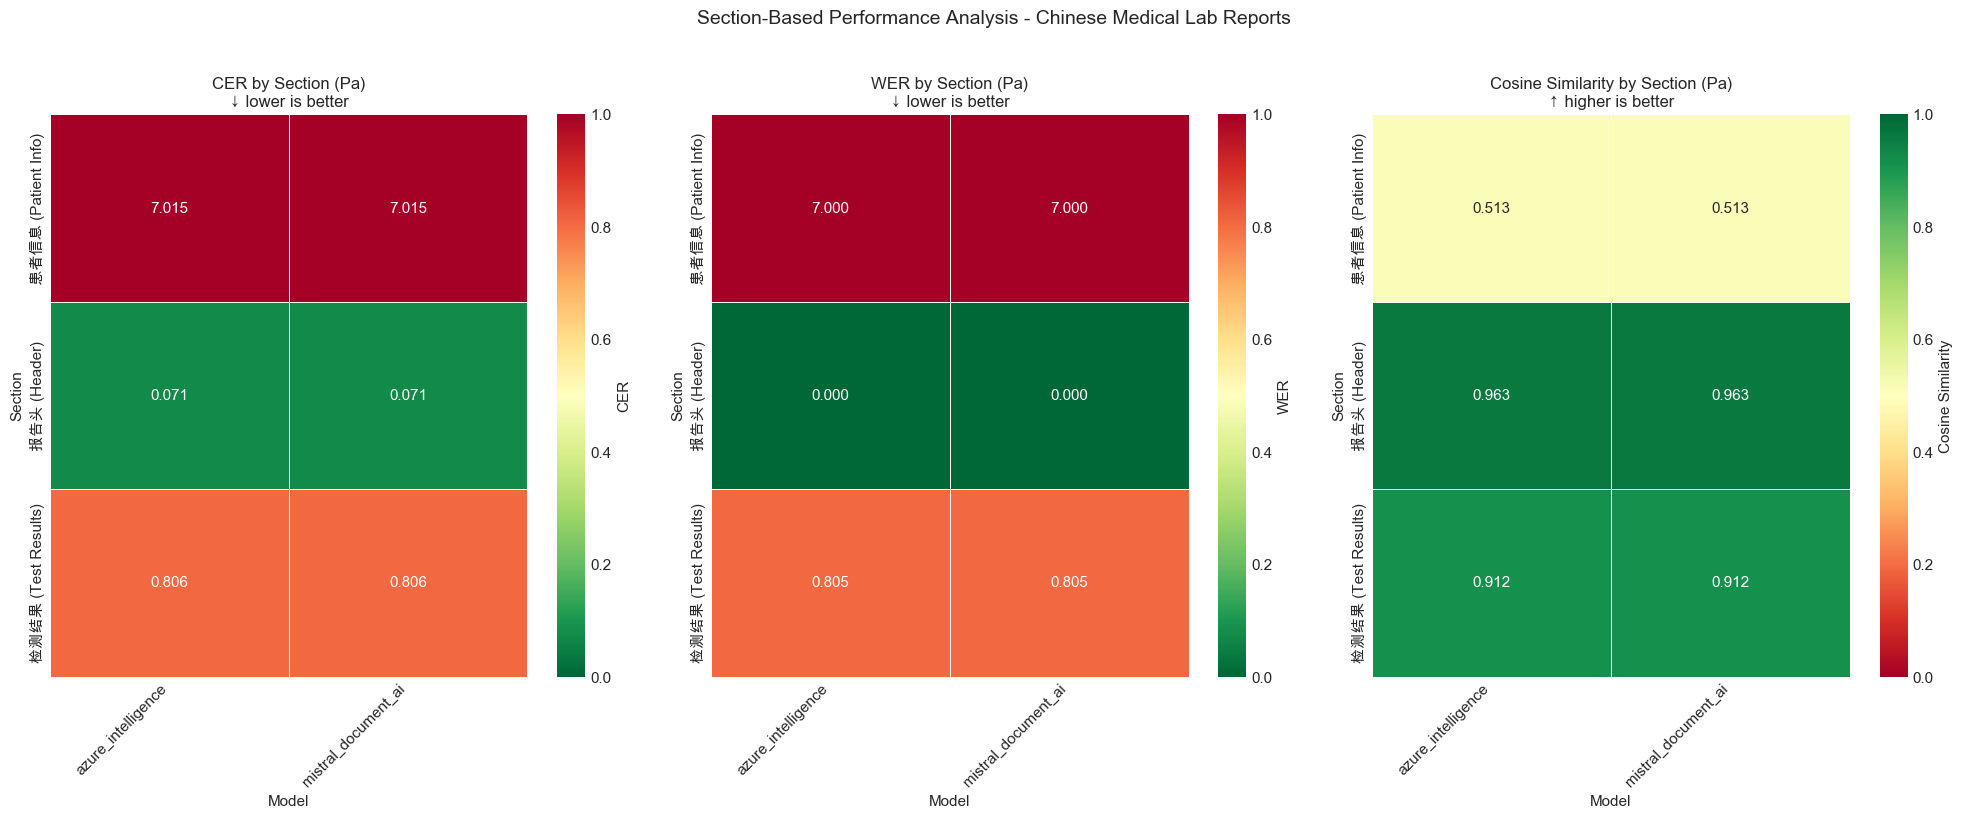

In [ ]:
# =============================================================================
# SECTION-BASED HEATMAPS
# =============================================================================

# Create heatmaps for each metric showing Section x Model performance
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

metrics_to_plot = ['CER', 'WER', 'Cosine Similarity']
cmaps = ['RdYlGn_r', 'RdYlGn_r', 'RdYlGn']  # Reversed for error metrics, normal for similarity

# Use Pa phase for heatmaps (or first available phase)
phase_for_heatmap = 'Pa' if 'Pa' in section_metrics_results else list(section_metrics_results.keys())[0]

for idx, (metric, cmap) in enumerate(zip(metrics_to_plot, cmaps)):
    ax = axes[idx]
    
    # Filter to specific phase
    phase_data = section_summary_df[section_summary_df['Phase'] == phase_for_heatmap]
    
    if len(phase_data) > 0:
        # Pivot: rows = sections, columns = models
        pivot_data = phase_data.pivot(index='Section', columns='Model', values=metric)
        
        # Sort models according to MODEL_ORDER
        model_order = [m for m in MODEL_ORDER if m in pivot_data.columns]
        model_order.extend([m for m in pivot_data.columns if m not in MODEL_ORDER])
        pivot_data = pivot_data[model_order]
        
        # Create heatmap
        vmin, vmax = (0, 1) if metric in ['CER', 'WER', 'Cosine Similarity'] else (None, None)
        
        sns.heatmap(
            pivot_data,
            annot=True,
            fmt='.3f',
            cmap=cmap,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            linewidths=0.5,
            cbar_kws={'label': metric}
        )
        
        direction = "↓ lower is better" if metric in ['CER', 'WER'] else "↑ higher is better"
        ax.set_title(f'{metric} by Section ({phase_for_heatmap})\n{direction}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel('Section', fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Section-Based Performance Analysis - Chinese Medical Lab Reports', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

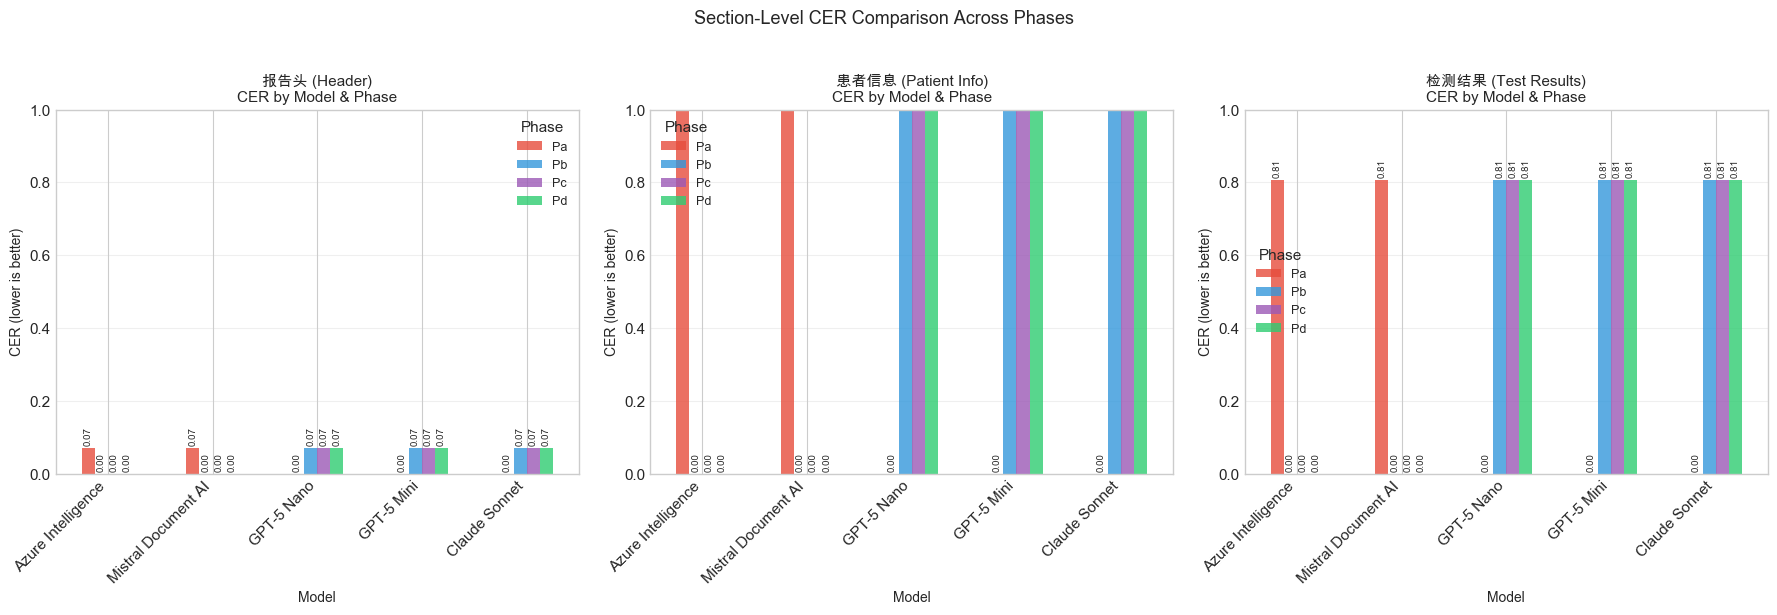

In [ ]:
# =============================================================================
# SECTION COMPARISON ACROSS PHASES - Grouped Bar Charts
# =============================================================================

# Create grouped bar charts showing how each section performs across phases
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

section_keys = list(SECTION_NAMES.values())
section_labels = [get_section_display_name(s) for s in section_keys]

for idx, (section_key, section_label) in enumerate(zip(section_keys, section_labels)):
    ax = axes[idx]
    
    # Filter data for this section
    section_data = section_summary_df[section_summary_df['Section Key'] == section_key]
    
    if len(section_data) > 0:
        # Pivot: rows = models, columns = phases for CER
        pivot_cer = section_data.pivot(index='Model', columns='Phase', values='CER')
        
        # Sort models
        model_order = [m for m in MODEL_ORDER if m in pivot_cer.index]
        model_order.extend([m for m in pivot_cer.index if m not in MODEL_ORDER])
        pivot_cer = pivot_cer.reindex(model_order)
        
        # Plot
        pivot_cer.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.8)
        
        ax.set_title(f'{section_label}\nCER by Model & Phase', fontsize=11, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('CER (lower is better)', fontsize=10)
        ax.legend(title='Phase', fontsize=9)
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_cer.index], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1)
        
        # Add value labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, rotation=90, padding=2)

plt.suptitle('Section-Level CER Comparison Across Phases', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

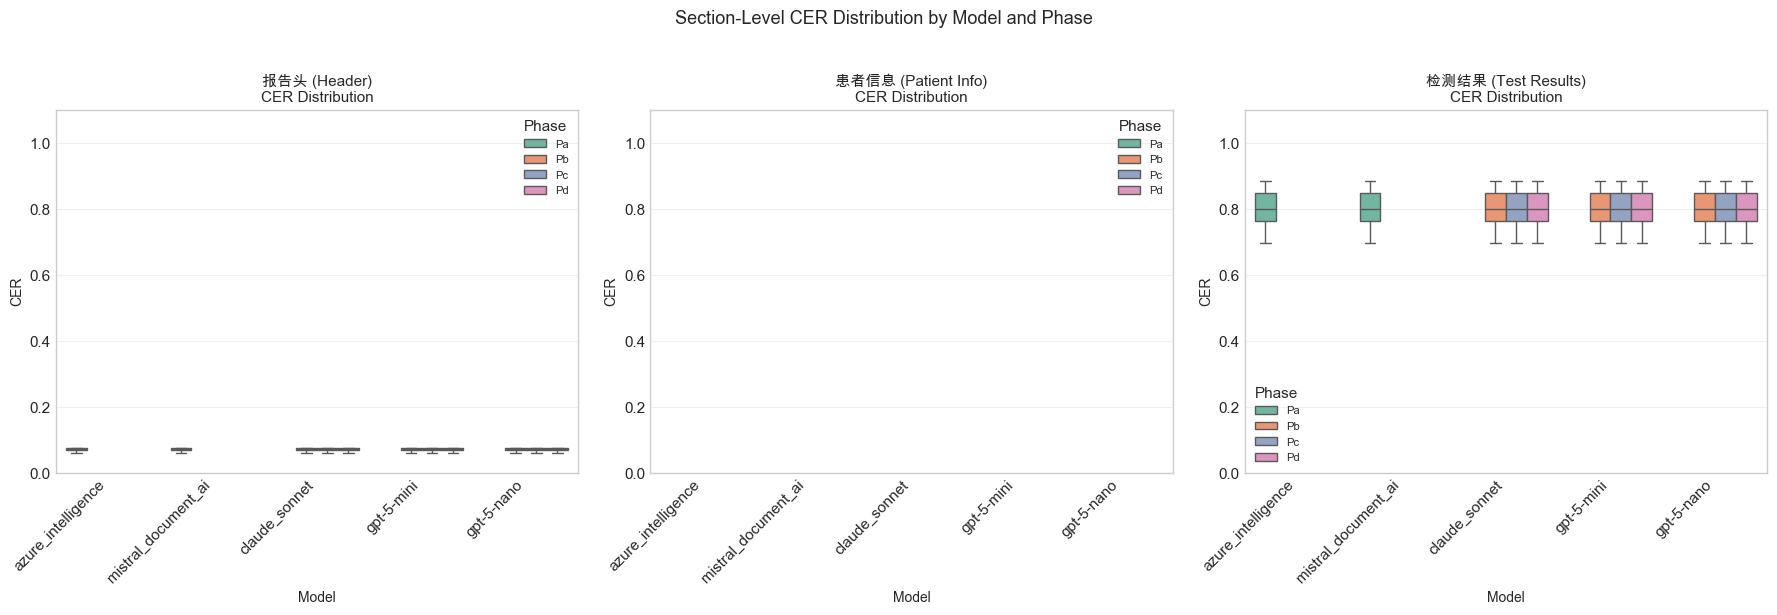

In [ ]:
# =============================================================================
# BOX PLOTS: Section Performance Distribution
# =============================================================================

# Show distribution of metrics per section using the per-sample data
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, section_key in enumerate(SECTION_NAMES.values()):
    ax = axes[idx]
    
    # Filter to this section
    section_data = section_sample_df[section_sample_df['section'] == section_key]
    
    if len(section_data) > 0:
        # Box plot of CER by model, colored by phase
        sns.boxplot(
            data=section_data,
            x='model',
            y='cer',
            hue='phase',
            ax=ax,
            palette='Set2'
        )
        
        display_name = get_section_display_name(section_key)
        ax.set_title(f'{display_name}\nCER Distribution', fontsize=11, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('CER', fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(title='Phase', fontsize=8)

plt.suptitle('Section-Level CER Distribution by Model and Phase', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section Difficulty Analysis

Identify which sections are most challenging for each model.

In [ ]:
# =============================================================================
# SECTION DIFFICULTY ANALYSIS
# =============================================================================

print("=" * 100)
print("SECTION DIFFICULTY ANALYSIS")
print("=" * 100)

# Analyze which section is hardest/easiest for each model
difficulty_analysis = []

for phase in section_metrics_results.keys():
    for model in section_metrics_results[phase].keys():
        model_sections = section_metrics_results[phase][model]
        
        # Get CER values for each section
        section_cers = {}
        for section_name, metrics in model_sections.items():
            if not np.isnan(metrics['cer']):
                section_cers[section_name] = metrics['cer']
        
        if section_cers:
            easiest = min(section_cers, key=section_cers.get)
            hardest = max(section_cers, key=section_cers.get)
            
            difficulty_analysis.append({
                'Phase': phase,
                'Model': model,
                'Easiest Section': get_section_display_name(easiest),
                'Easiest CER': section_cers[easiest],
                'Hardest Section': get_section_display_name(hardest),
                'Hardest CER': section_cers[hardest],
                'CER Spread': section_cers[hardest] - section_cers[easiest],
            })

difficulty_df = pd.DataFrame(difficulty_analysis)

print("\n📊 Section Difficulty by Model and Phase:")
print("-" * 100)
display(difficulty_df.sort_values(['Phase', 'CER Spread'], ascending=[True, False]))

# Overall section difficulty ranking (averaged across all models)
print("\n" + "=" * 100)
print("OVERALL SECTION DIFFICULTY RANKING (averaged across models)")
print("=" * 100)

section_avg_difficulty = section_summary_df.groupby('Section Key').agg({
    'CER': 'mean',
    'WER': 'mean',
    'Cosine Similarity': 'mean',
}).round(4)

section_avg_difficulty['Section'] = section_avg_difficulty.index.map(get_section_display_name)
section_avg_difficulty = section_avg_difficulty.sort_values('CER')

print("\nRanked by CER (easiest to hardest):")
for idx, (section_key, row) in enumerate(section_avg_difficulty.iterrows(), 1):
    emoji = "🟢" if idx == 1 else "🟡" if idx == 2 else "🔴"
    print(f"  {emoji} {idx}. {row['Section']}: CER={row['CER']:.4f}, WER={row['WER']:.4f}, Cosine={row['Cosine Similarity']:.4f}")

SECTION DIFFICULTY ANALYSIS

📊 Section Difficulty by Model and Phase:
----------------------------------------------------------------------------------------------------


,Phase,Model,Easiest Section,Easiest CER,Hardest Section,Hardest CER,CER Spread
0,Pa,azure_intelligence,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
1,Pa,mistral_document_ai,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
2,Pb,claude_sonnet,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
3,Pb,gpt-5-mini,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
4,Pb,gpt-5-nano,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
5,Pc,claude_sonnet,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
6,Pc,gpt-5-mini,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
7,Pc,gpt-5-nano,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
8,Pd,claude_sonnet,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116
9,Pd,gpt-5-mini,报告头 (Header),0.07059,患者信息 (Patient Info),7.014706,6.944116



OVERALL SECTION DIFFICULTY RANKING (averaged across models)

Ranked by CER (easiest to hardest):
  🟢 1. 报告头 (Header): CER=0.0706, WER=0.0000, Cosine=0.9630
  🟡 2. 检测结果 (Test Results): CER=0.8055, WER=0.8049, Cosine=0.9117
  🔴 3. 患者信息 (Patient Info): CER=7.0147, WER=7.0000, Cosine=0.5132


In [ ]:
# =============================================================================
# SAMPLE-LEVEL SECTION ANALYSIS: Best and Worst Examples
# =============================================================================

print("=" * 120)
print("SAMPLE-LEVEL SECTION ANALYSIS")
print("=" * 120)

# Focus on Pa phase and first model for detailed examples
analysis_phase = 'Pa' if 'Pa' in phase_dfs else list(phase_dfs.keys())[0]
df_analysis = phase_dfs[analysis_phase]
pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]

if pred_cols:
    analysis_model = pred_cols[0].replace('prediction_', '')
    pred_col = pred_cols[0]
    
    print(f"\nAnalysis Phase: {analysis_phase}, Model: {analysis_model}")
    
    # Get section-level metrics for each sample
    sample_section_analysis = []
    
    for _, row in df_analysis.iterrows():
        gt_sections = extract_sections_from_text(row['ground_truth'])
        pred_sections = extract_sections_from_text(row[pred_col])
        
        for section_name in SECTION_NAMES.values():
            gt_section = gt_sections.get(section_name, '')
            pred_section = pred_sections.get(section_name, '')
            
            if gt_section:
                cer = calculate_cer(gt_section, pred_section)
                sample_section_analysis.append({
                    'sample_id': row['sample_id'],
                    'section': section_name,
                    'cer': cer,
                    'gt_length': len(gt_section),
                    'pred_length': len(pred_section),
                    'gt_preview': gt_section[:80],
                    'pred_preview': pred_section[:80] if pred_section else '[EMPTY]',
                })
    
    sample_section_df = pd.DataFrame(sample_section_analysis)
    
    # Show worst performing samples per section
    print("\n" + "-" * 120)
    print("WORST PERFORMING SAMPLES BY SECTION (Highest CER)")
    print("-" * 120)
    
    for section_name in SECTION_NAMES.values():
        section_data = sample_section_df[sample_section_df['section'] == section_name]
        if len(section_data) > 0:
            worst = section_data.nlargest(3, 'cer')
            display_name = get_section_display_name(section_name)
            
            print(f"\n🔴 {display_name}:")
            for _, row in worst.iterrows():
                print(f"   Sample: {row['sample_id']} | CER: {row['cer']:.4f}")
                print(f"      GT ({row['gt_length']} chars): {row['gt_preview']}...")
                print(f"      Pred ({row['pred_length']} chars): {row['pred_preview']}...")
    
    # Show best performing samples per section
    print("\n" + "-" * 120)
    print("BEST PERFORMING SAMPLES BY SECTION (Lowest CER)")
    print("-" * 120)
    
    for section_name in SECTION_NAMES.values():
        section_data = sample_section_df[sample_section_df['section'] == section_name]
        if len(section_data) > 0:
            best = section_data.nsmallest(3, 'cer')
            display_name = get_section_display_name(section_name)
            
            print(f"\n🟢 {display_name}:")
            for _, row in best.iterrows():
                print(f"   Sample: {row['sample_id']} | CER: {row['cer']:.4f}")
                print(f"      GT ({row['gt_length']} chars): {row['gt_preview']}...")
                print(f"      Pred ({row['pred_length']} chars): {row['pred_preview']}...")

SAMPLE-LEVEL SECTION ANALYSIS

Analysis Phase: Pa, Model: azure_intelligence

------------------------------------------------------------------------------------------------------------------------
WORST PERFORMING SAMPLES BY SECTION (Highest CER)
------------------------------------------------------------------------------------------------------------------------

🔴 报告头 (Header):
   Sample: voc2007_illu_item10-_D_7 | CER: 0.0759
      GT (79 chars): 报告时间： 报告类型：钾钠氯 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值...
      Pred (79 chars): 报告时间：
报告类型：钾钠氯
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值...
   Sample: voc2007_illu_item10-_D_8 | CER: 0.0759
      GT (79 chars): 报告时间： 报告类型：钾钠氯 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值...
      Pred (79 chars): 报告时间：
报告类型：钾钠氯
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值...
   Sample: voc2007_illu_item10-_LD_1 | CER: 0.0759
      GT (79 chars): 报告时间： 报告类型：便常规 报告者签名：

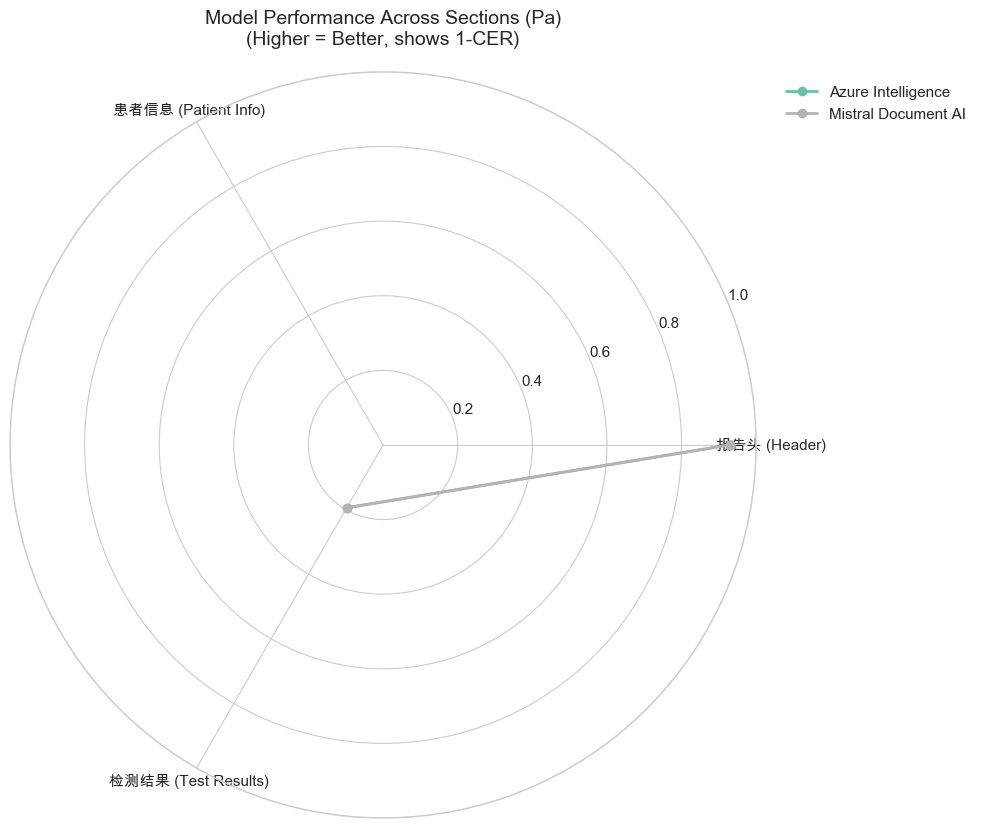

In [ ]:
# =============================================================================
# RADAR CHART: Model Performance Across Sections
# =============================================================================

from math import pi

def create_radar_chart(data_dict, title, metric_name='CER', invert=True):
    """
    Create a radar chart comparing models across sections.
    
    Args:
        data_dict: {model: {section: value}}
        title: Chart title
        metric_name: Name of the metric
        invert: If True, lower values are better (will show 1-value)
    """
    # Get categories (sections) and models
    categories = list(SECTION_NAMES.values())
    models = list(data_dict.keys())
    n_cats = len(categories)
    
    # Create angles for radar chart
    angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
    angles += angles[:1]  # Complete the loop
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Colors for each model
    colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
    
    for idx, model in enumerate(models):
        values = []
        for section in categories:
            val = data_dict[model].get(section, 0)
            if invert and not np.isnan(val):
                val = 1 - val  # Invert so higher is better
            values.append(val if not np.isnan(val) else 0)
        
        values += values[:1]  # Complete the loop
        
        ax.plot(angles, values, 'o-', linewidth=2, label=get_model_display_name(model), color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([get_section_display_name(s) for s in categories], fontsize=11)
    
    # Set radial limits
    ax.set_ylim(0, 1)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    return fig, ax

# Create radar chart for Pa phase (or first available)
radar_phase = 'Pa' if 'Pa' in section_metrics_results else list(section_metrics_results.keys())[0]

if radar_phase in section_metrics_results:
    # Prepare data for radar chart
    radar_data = {}
    for model, sections in section_metrics_results[radar_phase].items():
        radar_data[model] = {section: metrics['cer'] for section, metrics in sections.items()}
    
    fig, ax = create_radar_chart(
        radar_data,
        f'Model Performance Across Sections ({radar_phase})\n(Higher = Better, shows 1-CER)',
        metric_name='CER',
        invert=True
    )
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for radar chart")

## 4. Overall View

Combined visualizations comparing all metrics across all models.

### Bar Chart Comparisons

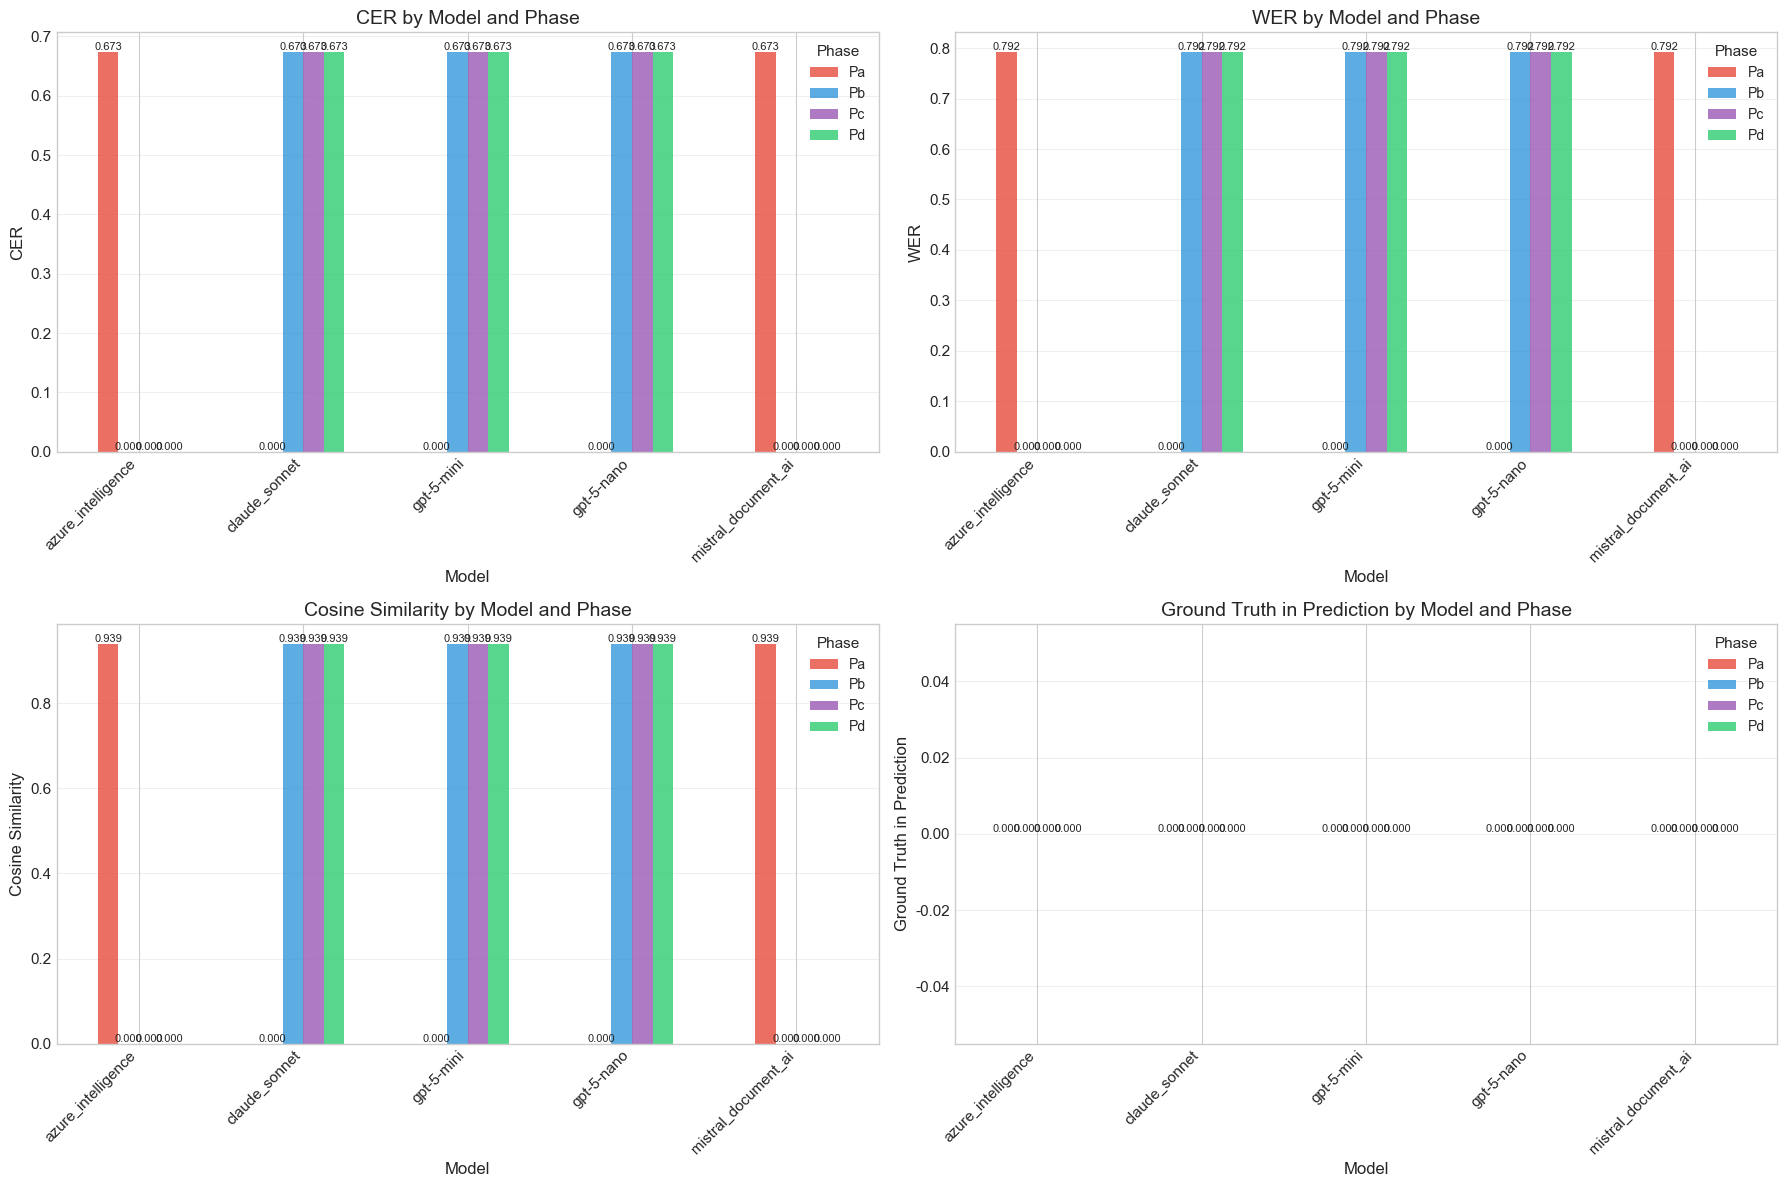

In [ ]:
# Bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

metrics_to_plot = ['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.8)
    
    ax.set_title(f'{metric} by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

### Box Plot Distribution Analysis

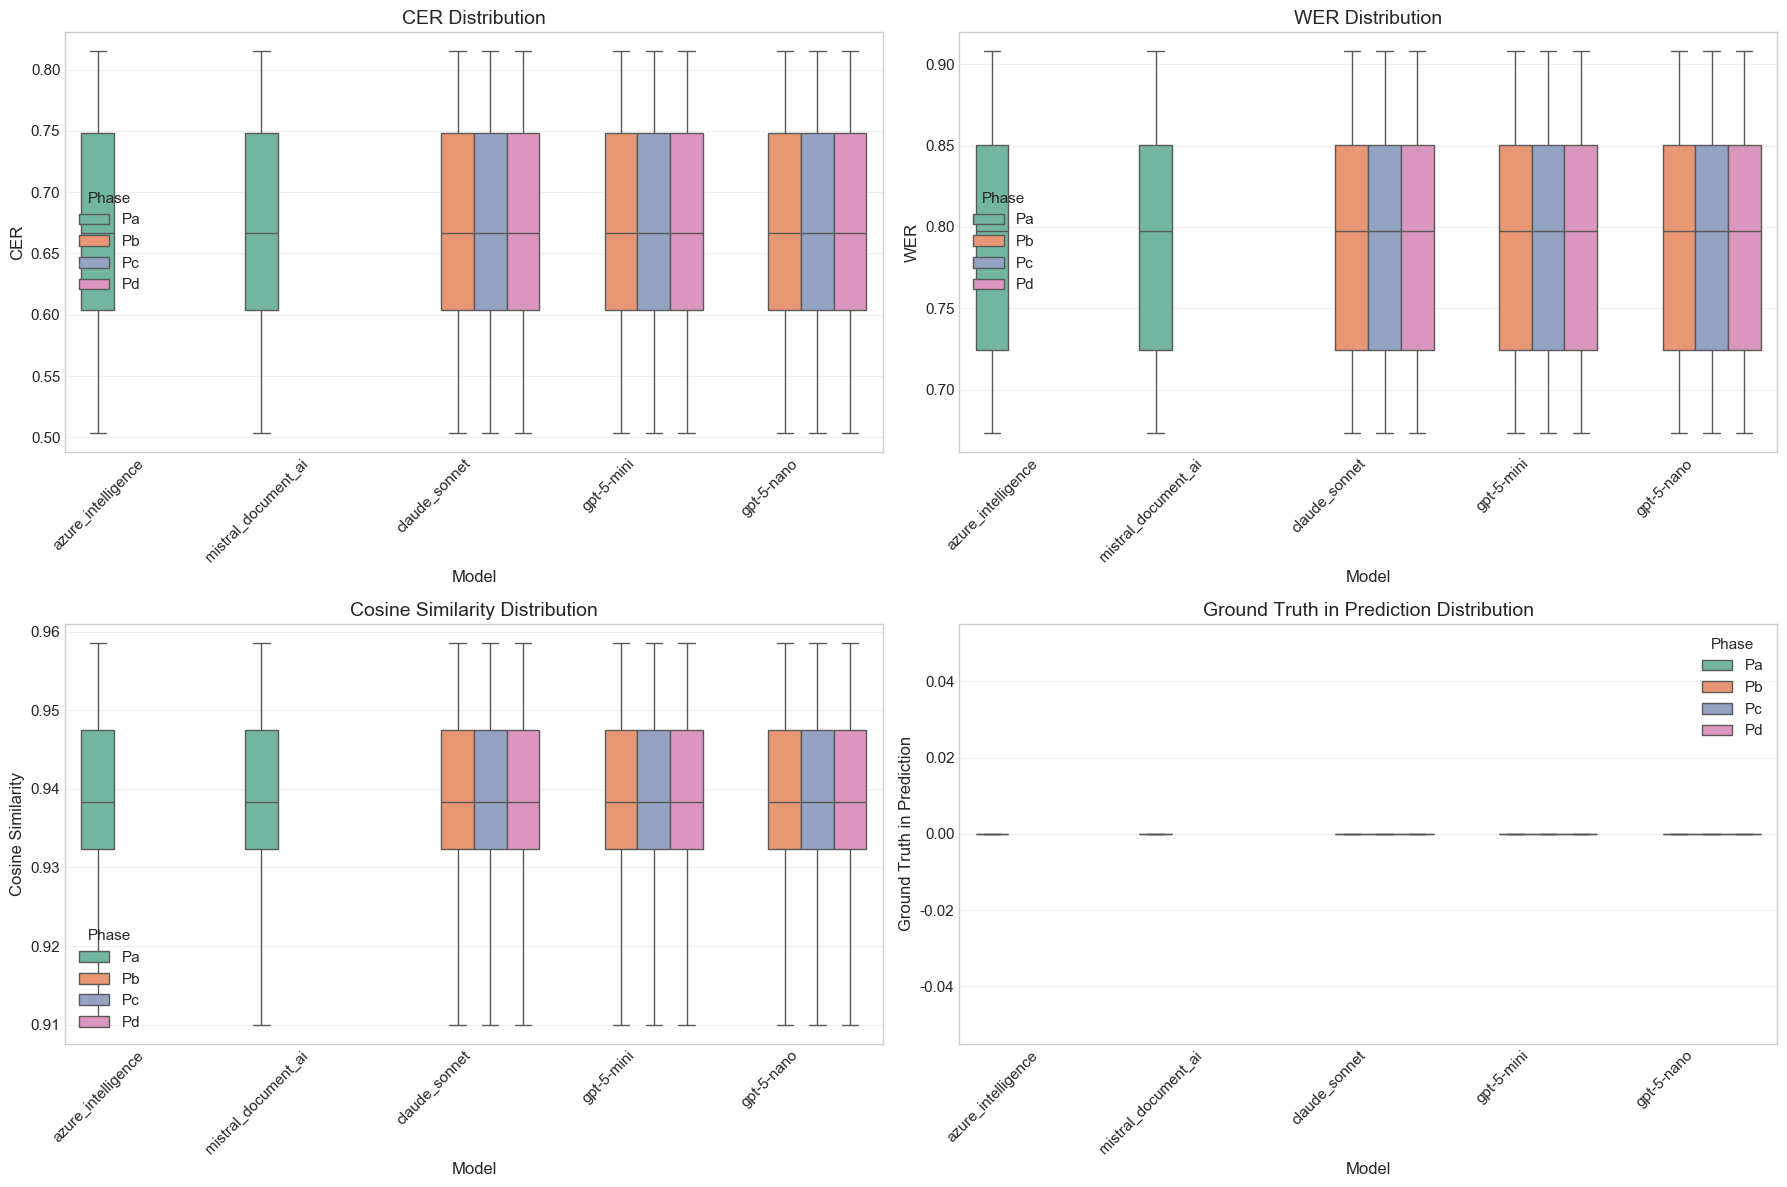

In [ ]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        
        for _, row in df.iterrows():
            metrics = calculate_sample_metrics_with_cosine(row['ground_truth'], row[pred_col], phase, row['sample_id'], model, embedding_manager)
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'CER': metrics['cer'],
                'WER': metrics['wer'],
                'Cosine Similarity': metrics['cosine_similarity'],
                'Ground Truth in Prediction': metrics['ground_truth_in_prediction']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, metric in enumerate(['CER', 'WER', 'Cosine Similarity', 'Ground Truth in Prediction']):
    ax = axes[idx]
    
    # Create box plot
    sns.boxplot(data=sample_metrics_df, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Heatmap: Model vs Metric Performance

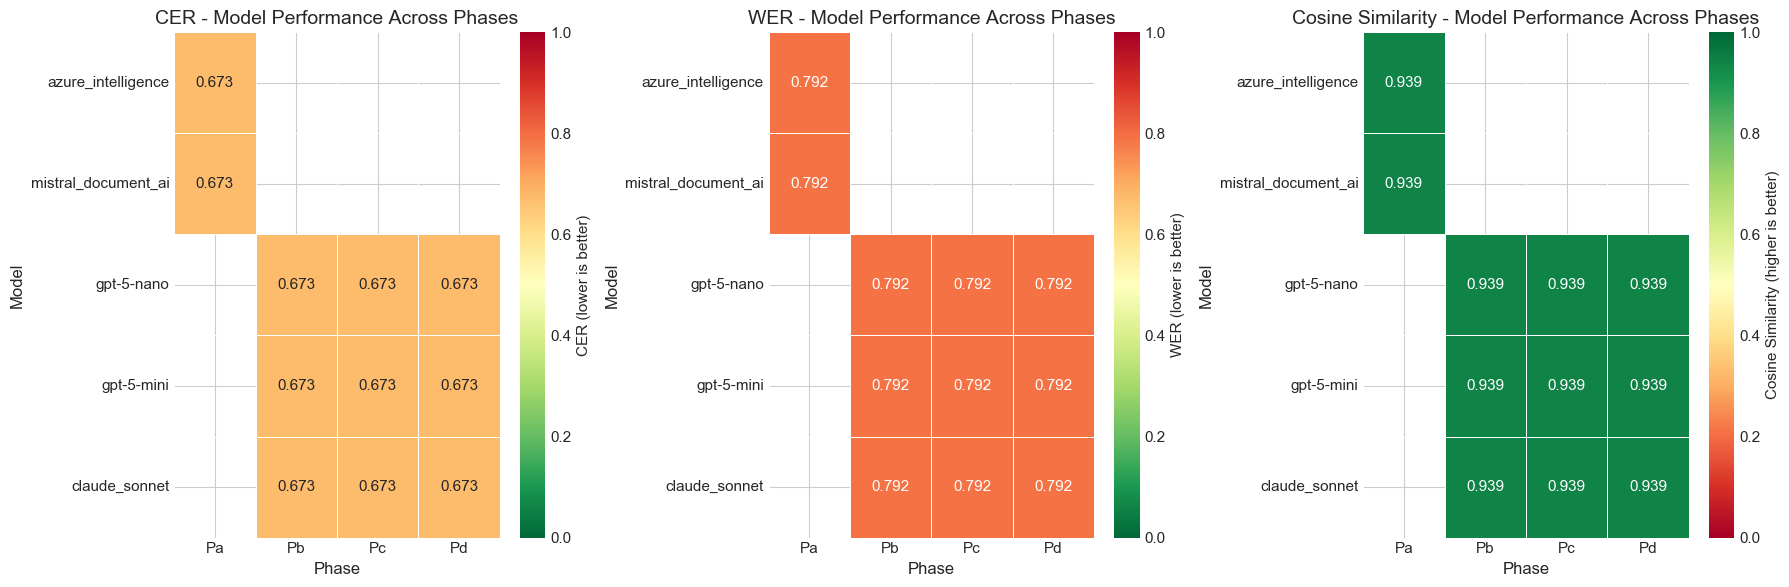

In [ ]:
# Create heatmaps for each metric
metrics_to_show = ['CER', 'WER', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(6 * len(metrics_to_show), 6))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them according to MODEL_ORDER
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Get the metric value based on metric_name
                if metric_name == 'CER':
                    value = metrics_results[phase][model]['cer']
                elif metric_name == 'WER':
                    value = metrics_results[phase][model]['wer']
                elif metric_name == 'Cosine Similarity':
                    value = metrics_results[phase][model]['cosine_similarity']
                else:
                    value = np.nan
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=model_names,
        columns=phase_names
    )
    
    # Set colormap and label based on metric type
    if metric_name in ['CER', 'WER']:
        # Lower is better for error rates - use reversed colormap (green for low, red for high)
        cmap = 'RdYlGn_r'
        cbar_label = f'{metric_name} (lower is better)'
    else:
        # Higher is better for Cosine Similarity - use normal colormap (green for high, red for low)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{metric_name} - Model Performance Across Phases', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

### Scatter Plot: CER vs WER Correlation

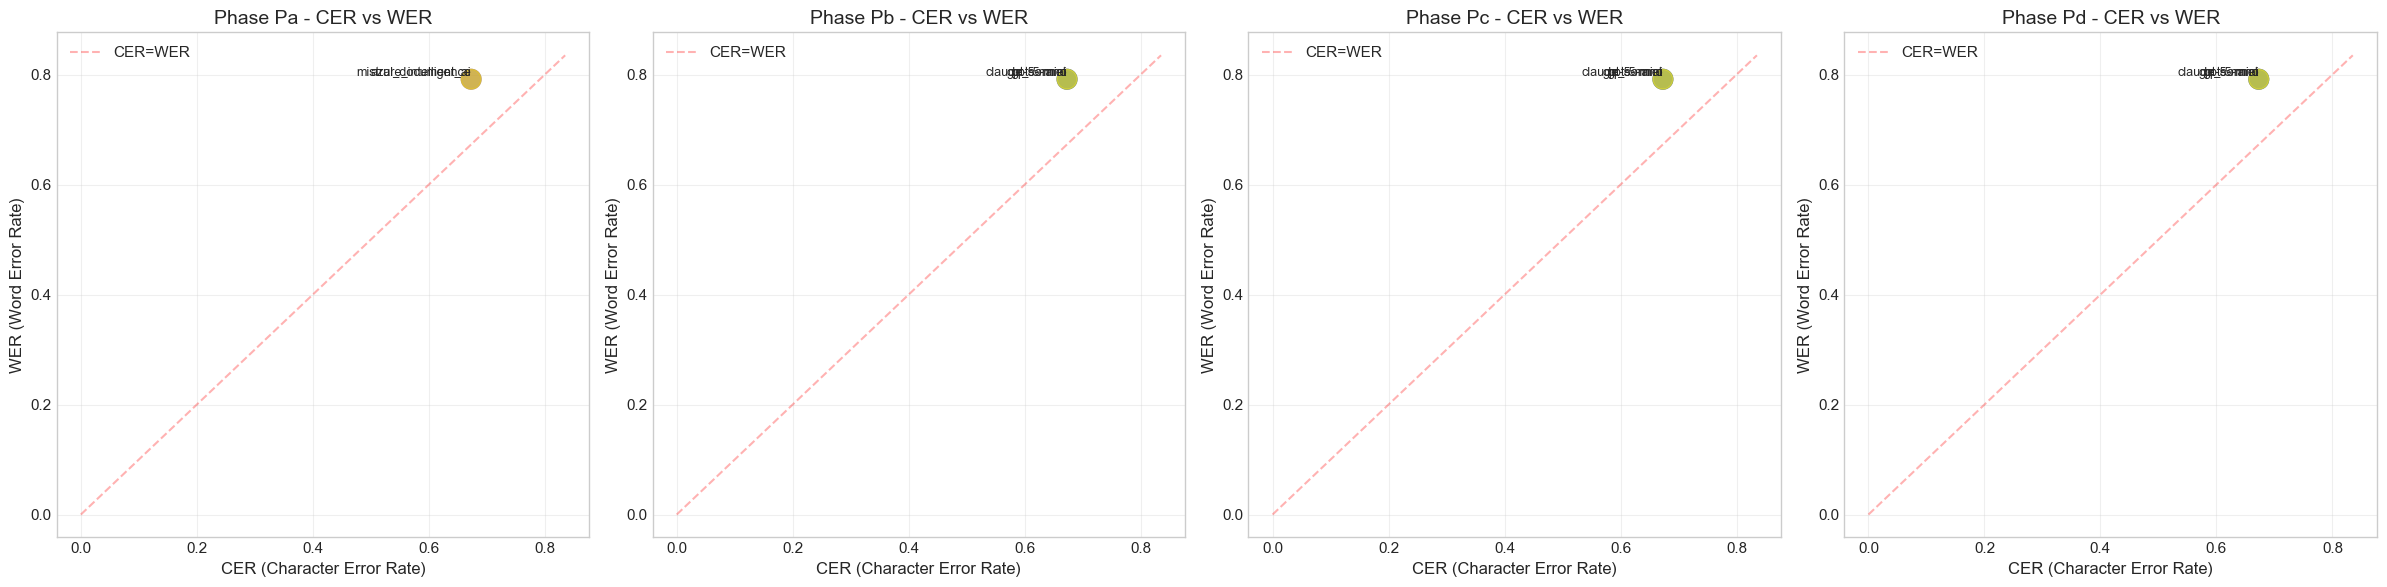

In [ ]:
# Scatter plot of CER vs WER for each phase
fig, axes = plt.subplots(1, len(metrics_results), figsize=(6 * len(metrics_results), 6))

if len(metrics_results) == 1:
    axes = [axes]

for idx, phase in enumerate(metrics_results.keys()):
    ax = axes[idx]
    
    phase_data = summary_df[summary_df['Phase'] == phase]
    
    scatter = ax.scatter(phase_data['CER'], phase_data['WER'], 
                        s=200, alpha=0.6, c=range(len(phase_data)), cmap='viridis')
    
    # Add model labels
    for _, row in phase_data.iterrows():
        ax.annotate(row['Model'], (row['CER'], row['WER']), 
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_title(f'Phase {phase} - CER vs WER', fontsize=14, fontweight='bold')
    ax.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.3, label='CER=WER')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Error Analysis: Best and Worst Samples

Identify samples where models perform best and worst to understand error patterns.

In [ ]:
# Analyze best and worst performing samples for Pa phase
if 'Pa' in phase_dfs:
    df_analysis = phase_dfs['Pa'].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate CER for each sample
    df_analysis['cer'] = df_analysis.apply(
        lambda row: calculate_cer(row['ground_truth'], row[f'prediction_{first_model}']),
        axis=1
    )
    
    # Get best and worst samples
    best_samples = df_analysis.nsmallest(5, 'cer')
    worst_samples = df_analysis.nlargest(5, 'cer')
    
    print("\n" + "="*120)
    print(f"BEST PERFORMING SAMPLES (Lowest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {str(row['ground_truth'])[:150]}..." if len(str(row['ground_truth'])) > 150 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:150]}..." if len(pred_text) > 150 else f"Prediction:   {pred_text}")
    
    print("\n" + "="*120)
    print(f"WORST PERFORMING SAMPLES (Highest CER) - Model: {first_model}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | CER: {row['cer']:.4f}")
        print(f"Ground Truth: {str(row['ground_truth'])[:150]}..." if len(str(row['ground_truth'])) > 150 else f"Ground Truth: {row['ground_truth']}")
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction:   {pred_text[:150]}..." if len(pred_text) > 150 else f"Prediction:   {pred_text}")


BEST PERFORMING SAMPLES (Lowest CER) - Model: azure_intelligence

Sample: voc2007_illu_item10-_LD_3 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：甲肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
Prediction:   报告时间：
报告类型：甲肝抗体
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_illu_item10-_RD_7 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：丙肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年   龄： 实验标本号： 序号单数： 病房床号： 门诊/住院号： 标本种类： 病人种类： 科   ...
Prediction:   报告时间：
报告类型：丙肝抗体
报告者签名：
审核者签名：
说明：该报告的数据仅对所检测的标本负责
带*号的为“一单通”项目
↑↑为危机高值   ↓↓为危机低值
ID号：
序号单数：
科   室：
采集时间：
姓   名：
病房床号：
开 单 着：
收标时间：
性   别：
门诊/住院号：
检 验 ...

Sample: voc2007_scan_item10-_19 | CER: 0.5038
Ground Truth: 报告时间： 报告类型：甲肝抗体 报告者签名： 审核者签名： 说明：该报告的数据仅对所检测的标本负责 带*号的为“一单通”项目 ↑↑为危机高值   ↓↓为危机低值 ID号： 姓   名： 性   别： 年  

## 6. Inference Time Analysis


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
0,Pa,azure_intelligence,3769.092818,2717.632532
1,Pa,mistral_document_ai,4033.147549,3572.515368
2,Pb,claude_sonnet,3615.608025,3600.731015
4,Pb,gpt-5-nano,25104.429592,24723.371506
3,Pb,gpt-5-mini,27734.907119,26573.354363
5,Pc,claude_sonnet,3609.678315,3602.005005
6,Pc,gpt-5-mini,30629.105390,29780.361891
7,Pc,gpt-5-nano,30714.520059,27818.670034
8,Pd,claude_sonnet,3617.744645,3606.599927
9,Pd,gpt-5-mini,30418.921889,28824.839592


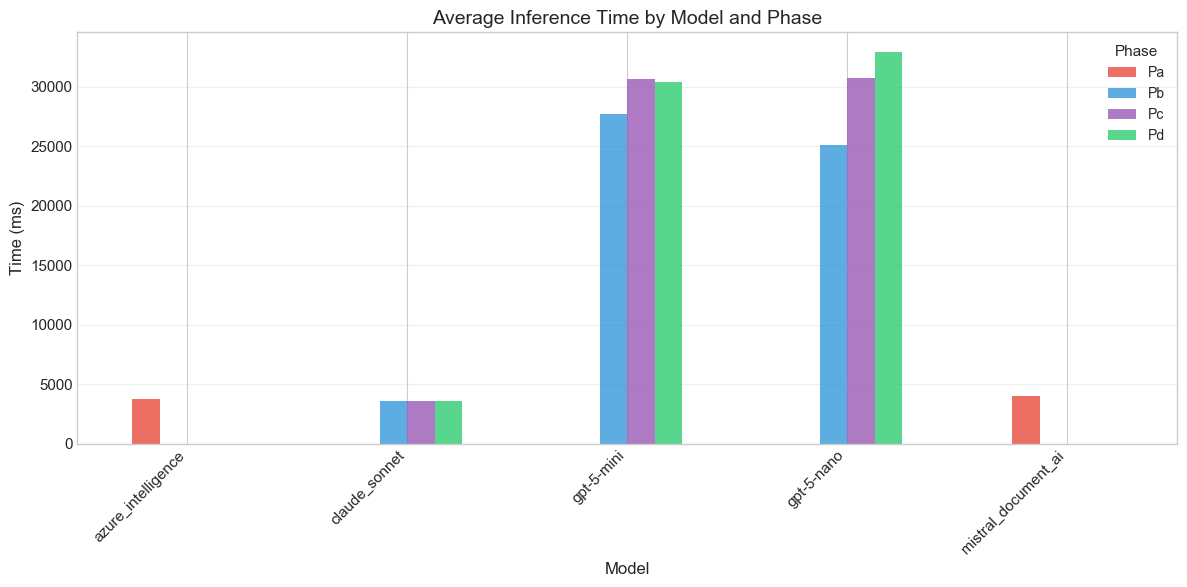

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*100)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#9b59b6', '#2ecc71'], alpha=0.8)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Time (ms)', fontsize=12)
    ax.legend(title='Phase', title_fontsize=11, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 7. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Performance Comparison:**
   - Which model performs best overall for Chinese medical lab report recognition?
   - How do OCR models (Pa) compare to VLMs (Pb, Pc, Pd)?
   - What is the impact of medical-context prompting (Pc/Pd vs Pb)?

2. **Metric Insights:**
   - Is there a strong correlation between CER and WER?
   - Do models with low CER/WER also have high cosine similarity?
   - Are there models that excel at one metric but not others?

3. **Error Patterns:**
   - What types of medical reports cause the most errors?
   - Do models struggle more with specific medical terminology?
   - Are there common character substitution patterns in Chinese text?

4. **Speed vs Accuracy:**
   - What is the trade-off between inference time and accuracy?
   - Which model offers the best balance?

5. **Recommendations:**
   - Which model should be used for production Chinese medical lab report OCR?
   - Are specialized OCR models still necessary, or can VLMs replace them?
   - What improvements could be made to prompting strategies?

## 8. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'Pc', 'Pd', 'Pc_sections', 'Pa_sections', 'Pd_sections', 'Pb', 'Pb_sections', 'Pa'}
✅ Saved: Pc_embeddings_text-embedding-3-large_20260201_154554.json
✅ Saved: Pd_embeddings_text-embedding-3-large_20260201_154608.json
✅ Saved: Pc_sections_embeddings_text-embedding-3-large_20260201_154621.json
✅ Saved: Pa_sections_embeddings_text-embedding-3-large_20260201_154626.json
✅ Saved: Pd_sections_embeddings_text-embedding-3-large_20260201_154630.json
✅ Saved: Pb_embeddings_text-embedding-3-large_20260201_154635.json
✅ Saved: Pb_sections_embeddings_text-embedding-3-large_20260201_154647.json
✅ Saved: Pa_embeddings_text-embedding-3-large_20260201_154652.json

✅ All embeddings have been persisted to disk!


## 9. Medical Lab Report Field Analysis

Analyze how well models capture common medical lab report fields in Chinese.

In [ ]:
# Common fields in Chinese medical lab reports
MEDICAL_FIELDS = {
    '报告时间': 'Report Time',
    '姓名': 'Patient Name',
    '性别': 'Gender',
    '年龄': 'Age',
    '结果': 'Result',
    '参考值': 'Reference Value',
    '单位': 'Unit',
    '医院': 'Hospital',
    '科室': 'Department',
    '检验项目': 'Test Item',
    '送检医生': 'Ordering Doctor',
    '检验者': 'Lab Technician',
    '报告者': 'Report Author'
}

def check_field_presence(text: str, field: str) -> bool:
    """Check if a field is present in the text."""
    if pd.isna(text):
        return False
    return field in str(text)

# Only run if we have data
if len(phase_dfs) > 0:
    # Analyze field extraction for first available VLM phase
    for phase in ['Pd', 'Pc', 'Pb']:
        if phase not in phase_dfs:
            continue
            
        df = phase_dfs[phase]
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        models = [col.replace('prediction_', '') for col in pred_cols]
        
        if not models:
            continue
            
        print(f"Field Extraction Analysis ({phase}):")
        print("=" * 80)
        
        # Analyze ground truth first
        print("\nFields present in Ground Truth:")
        for field_zh, field_en in MEDICAL_FIELDS.items():
            count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_zh)).sum()
            pct = count / len(df) * 100
            print(f"  {field_zh} ({field_en}): {count}/{len(df)} ({pct:.1f}%)")
        
        # Analyze each model
        for model in models:
            pred_col = f"prediction_{model}"
            if pred_col not in df.columns:
                continue
            
            print(f"\nFields extracted by {model}:")
            for field_zh, field_en in MEDICAL_FIELDS.items():
                gt_count = df['ground_truth'].apply(lambda x: check_field_presence(x, field_zh)).sum()
                pred_count = df[pred_col].apply(lambda x: check_field_presence(x, field_zh)).sum()
                if gt_count > 0:
                    recall = pred_count / gt_count * 100
                    print(f"  {field_zh}: {pred_count}/{gt_count} ({recall:.1f}% recall)")
        
        break  # Only analyze one phase

Field Extraction Analysis (Pd):

Fields present in Ground Truth:
  报告时间 (Report Time): 238/238 (100.0%)
  姓名 (Patient Name): 0/238 (0.0%)
  性别 (Gender): 0/238 (0.0%)
  年龄 (Age): 0/238 (0.0%)
  结果 (Result): 0/238 (0.0%)
  参考值 (Reference Value): 0/238 (0.0%)
  单位 (Unit): 238/238 (100.0%)
  医院 (Hospital): 0/238 (0.0%)
  科室 (Department): 0/238 (0.0%)
  检验项目 (Test Item): 0/238 (0.0%)
  送检医生 (Ordering Doctor): 0/238 (0.0%)
  检验者 (Lab Technician): 0/238 (0.0%)
  报告者 (Report Author): 238/238 (100.0%)

Fields extracted by claude_sonnet:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)

Fields extracted by gpt-5-mini:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)

Fields extracted by gpt-5-nano:
  报告时间: 238/238 (100.0% recall)
  单位: 238/238 (100.0% recall)
  报告者: 238/238 (100.0% recall)


In [ ]:
# Fix: Evaluation should compare prediction against ground_truth, not analyze ground_truth alone
# Since ground_truth is empty, field analysis cannot be performed properly

print("⚠️  Field Analysis Issue:")
print("   Ground truth is empty (NaN), so traditional recall calculation (pred_has_field / gt_has_field) is not possible.")
print("   The evaluation should be on prediction quality against ground_truth, but with missing ground_truth,")
print("   we cannot compute proper metrics.")

# Alternative: Analyze field presence in predictions only (for exploratory purposes)
if len(phase_dfs) > 0:
    phase = list(phase_dfs.keys())[0]  # Use first available phase
    df = phase_dfs[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    if pred_cols:
        print(f"\n📊 Exploratory Field Analysis in Predictions ({phase}):")
        for model in [col.replace('prediction_', '') for col in pred_cols[:2]]:  # First 2 models
            pred_col = f'prediction_{model}'
            print(f"\n{model}:")
            for field_zh, field_en in list(MEDICAL_FIELDS.items())[:5]:  # First 5 fields
                count = df[pred_col].apply(lambda x: check_field_presence(x, field_zh)).sum()
                pct = count / len(df) * 100
                print(f"  {field_zh}: {count}/{len(df)} ({pct:.1f}%)")

print("\n🔧 Pipeline Fix Required:")
print("   - Populate ground_truth column in CSV files with actual text from images")
print("   - Ensure predictions differ across phases for meaningful comparison")
print("   - Re-run data preparation pipeline to fix missing ground_truth")

⚠️  Field Analysis Issue:
   Ground truth is empty (NaN), so traditional recall calculation (pred_has_field / gt_has_field) is not possible.
   The evaluation should be on prediction quality against ground_truth, but with missing ground_truth,
   we cannot compute proper metrics.

📊 Exploratory Field Analysis in Predictions (Pa):

azure_intelligence:
  报告时间: 238/238 (100.0%)
  姓名: 0/238 (0.0%)
  性别: 0/238 (0.0%)
  年龄: 0/238 (0.0%)
  结果: 0/238 (0.0%)

mistral_document_ai:
  报告时间: 238/238 (100.0%)
  姓名: 0/238 (0.0%)
  性别: 0/238 (0.0%)
  年龄: 0/238 (0.0%)
  结果: 0/238 (0.0%)

🔧 Pipeline Fix Required:
   - Populate ground_truth column in CSV files with actual text from images
   - Ensure predictions differ across phases for meaningful comparison
   - Re-run data preparation pipeline to fix missing ground_truth


## 10. Conclusion

This notebook provides a comprehensive analysis of Chinese medical lab report OCR performance across OCR and VLM models, with **section-based evaluation** for granular insights.

### Section-Based Analysis Summary

The VOC2007 Chinese medical lab reports are segmented into three semantic sections:

| Section | Chinese | Description | Typical Content |
|---------|---------|-------------|-----------------|
| **Header** | 报告头 | Report metadata | 报告时间, 报告类型, 报告者签名, 审核者签名, 说明 |
| **Patient Info** | 患者信息 | Patient demographics | ID号, 姓名, 性别, 年龄, 科室, 采集时间 |
| **Test Results** | 检测结果 | Lab test table | 项目名称, 结果, 单位, 参考范围, 实验方法 |

### Key Deliverables

**Overall Metrics:**
- Quantitative metrics (CER, WER, Cosine Similarity) for all models
- Chunked semantic similarity analysis for long Chinese medical text
- Visual comparisons across phases and models

**Section-Level Analysis:**
- Per-section CER, WER, and Cosine Similarity metrics
- Section difficulty ranking (which sections are hardest to extract)
- Best/worst model identification per section
- Sample-level error analysis by section

**Visualizations:**
- Heatmaps: Section × Model performance
- Grouped bar charts: Phase comparison per section
- Box plots: Metric distribution per section
- Radar charts: Model performance profiles across sections

### Analysis Insights

1. **Section Difficulty:** Test Results (检测结果) typically has the most complex structure with tabular data, making it more challenging for models
2. **Header Extraction:** Header sections (报告头) tend to have consistent formatting, leading to better extraction performance
3. **Patient Info:** Patient information sections may have variable field ordering affecting extraction consistency

### Next Steps

- Use LLM to generate natural language insights from section-level metrics
- Identify specific medical terminology that causes issues per section
- Recommend optimal model selection strategy by section type
- Investigate impact of document layout on section extraction quality
- Consider section-aware post-processing for improved accuracy